In [134]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib

 ## Data Collection:

In [135]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [136]:
df = pd.read_csv('Property_data.csv')

In [137]:
df.shape

(1460, 81)

In [138]:
df.head()

,PropertyID,PropertyClass,PropertyZone,PropertyFrontage,PropertySize,Street,Alley,PropertyShape,Elevation,Amenities,Orientation,Grade,Neighborhood,Condition1,Condition2,BldgType,PropertyStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Roof1Material,Roof2Material,ExteriorCladdingType,ExteriorCladdingArea,ExterQual,ExterCond,PropertyFooting,BsmntFinish,BsmntMaintenance,BsmntVisibility,BsmntFinRat1,BsmntFinSty1,BsmntFinQual1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,Heating,HeatingEfficiency,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,KitchenQual,CntRmsUpLev,Functional,CntFireplaces,QualFireplace,BasementType,BasementYrBlt,BasementFinish,BasementCars,BasementSqFootage,BasementQual,BasementCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,BoundaryFeatures,AddFeatures,AddVal,SaleMon,SaleYr,SaleType,SaleCondn,PropPrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PropertyID            1460 non-null   int64  
 1   PropertyClass         1460 non-null   int64  
 2   PropertyZone          1460 non-null   object 
 3   PropertyFrontage      1201 non-null   float64
 4   PropertySize          1460 non-null   int64  
 5   Street                1460 non-null   object 
 6   Alley                 91 non-null     object 
 7   PropertyShape         1460 non-null   object 
 8   Elevation             1460 non-null   object 
 9   Amenities             1460 non-null   object 
 10  Orientation           1460 non-null   object 
 11  Grade                 1460 non-null   object 
 12  Neighborhood          1460 non-null   object 
 13  Condition1            1460 non-null   object 
 14  Condition2            1460 non-null   object 
 15  BldgType             

In [140]:
df.describe()

,PropertyID,PropertyClass,PropertyFrontage,PropertySize,OverallQual,OverallCond,YearBuilt,YearRemodAdd,ExteriorCladdingArea,BsmntFinSty1,BsmtFinSF2,BsmtUnfSF,BsmntSqFtage,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,Bath1,Bath2,BedroomUpLev,KitchenUpLev,CntRmsUpLev,CntFireplaces,BasementYrBlt,BasementCars,BasementSqFootage,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,AddVal,SaleMon,SaleYr,PropPrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [141]:
df.columns.tolist()

['PropertyID',
 'PropertyClass',
 'PropertyZone',
 'PropertyFrontage',
 'PropertySize',
 'Street',
 'Alley',
 'PropertyShape',
 'Elevation',
 'Amenities',
 'Orientation',
 'Grade',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'PropertyStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Roof1Material',
 'Roof2Material',
 'ExteriorCladdingType',
 'ExteriorCladdingArea',
 'ExterQual',
 'ExterCond',
 'PropertyFooting',
 'BsmntFinish',
 'BsmntMaintenance',
 'BsmntVisibility',
 'BsmntFinRat1',
 'BsmntFinSty1',
 'BsmntFinQual1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'BsmntSqFtage',
 'Heating',
 'HeatingEfficiency',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'Bath1',
 'Bath2',
 'BedroomUpLev',
 'KitchenUpLev',
 'KitchenQual',
 'CntRmsUpLev',
 'Functional',
 'CntFireplaces',
 'QualFireplace',
 'BasementType',
 'BasementYrBlt',
 'BasementFinish',
 'BasementCars',

In [142]:
df.isnull().sum()

PropertyID                 0
PropertyClass              0
PropertyZone               0
PropertyFrontage         259
PropertySize               0
Street                     0
Alley                   1369
PropertyShape              0
Elevation                  0
Amenities                  0
Orientation                0
Grade                      0
Neighborhood               0
Condition1                 0
Condition2                 0
BldgType                   0
PropertyStyle              0
OverallQual                0
OverallCond                0
YearBuilt                  0
YearRemodAdd               0
RoofStyle                  0
RoofMatl                   0
Roof1Material              0
Roof2Material              0
ExteriorCladdingType     872
ExteriorCladdingArea       8
ExterQual                  0
ExterCond                  0
PropertyFooting            0
BsmntFinish               37
BsmntMaintenance          37
BsmntVisibility           38
BsmntFinRat1              37
BsmntFinSty1  

 ## Data Cleaning:

In [143]:
null=df.isnull().any()
null_values = null[null==True].index.tolist()
null_values

['PropertyFrontage',
 'Alley',
 'ExteriorCladdingType',
 'ExteriorCladdingArea',
 'BsmntFinish',
 'BsmntMaintenance',
 'BsmntVisibility',
 'BsmntFinRat1',
 'BsmntFinQual1',
 'Electrical',
 'QualFireplace',
 'BasementType',
 'BasementYrBlt',
 'BasementFinish',
 'BasementQual',
 'BasementCond',
 'PoolQC',
 'BoundaryFeatures',
 'AddFeatures']

In [144]:
# can't drop any columns except PropertyID as mentioned in the project document. 

df=df.drop(columns=['PropertyID'])

In [145]:
#handling missing values using median/mode

for c in null_values:
    if df[c].dtype == 'object':
        df[c].fillna(df[c].mode()[0], inplace=True)
    else:
        df[c].fillna(df[c].median(), inplace=True)

/var/folders/3l/fg0wzw9s7tq9np0dfwzzmpvc0000gn/T/ipykernel_15446/2181114065.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)
/var/folders/3l/fg0wzw9s7tq9np0dfwzzmpvc0000gn/T/ipykernel_15446/2181114065.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [146]:
df.isnull().sum()

PropertyClass           0
PropertyZone            0
PropertyFrontage        0
PropertySize            0
Street                  0
Alley                   0
PropertyShape           0
Elevation               0
Amenities               0
Orientation             0
Grade                   0
Neighborhood            0
Condition1              0
Condition2              0
BldgType                0
PropertyStyle           0
OverallQual             0
OverallCond             0
YearBuilt               0
YearRemodAdd            0
RoofStyle               0
RoofMatl                0
Roof1Material           0
Roof2Material           0
ExteriorCladdingType    0
ExteriorCladdingArea    0
ExterQual               0
ExterCond               0
PropertyFooting         0
BsmntFinish             0
BsmntMaintenance        0
BsmntVisibility         0
BsmntFinRat1            0
BsmntFinSty1            0
BsmntFinQual1           0
BsmtFinSF2              0
BsmtUnfSF               0
BsmntSqFtage            0
Heating     

In [147]:
#check any existing duplicate columns

df.duplicated().sum()

np.int64(0)

 ## EDA:

In [148]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['PropertyClass', 'PropertyFrontage', 'PropertySize', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'ExteriorCladdingArea',
       'BsmntFinSty1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmntSqFtage', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'Bath1', 'Bath2', 'BedroomUpLev', 'KitchenUpLev', 'CntRmsUpLev',
       'CntFireplaces', 'BasementYrBlt', 'BasementCars', 'BasementSqFootage',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'AddVal', 'SaleMon', 'SaleYr', 'PropPrice'],
      dtype='object')

In [149]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols

Index(['PropertyZone', 'Street', 'Alley', 'PropertyShape', 'Elevation',
       'Amenities', 'Orientation', 'Grade', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'PropertyStyle', 'RoofStyle', 'RoofMatl',
       'Roof1Material', 'Roof2Material', 'ExteriorCladdingType', 'ExterQual',
       'ExterCond', 'PropertyFooting', 'BsmntFinish', 'BsmntMaintenance',
       'BsmntVisibility', 'BsmntFinRat1', 'BsmntFinQual1', 'Heating',
       'HeatingEfficiency', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'QualFireplace', 'BasementType', 'BasementFinish',
       'BasementQual', 'BasementCond', 'PavedDrive', 'PoolQC',
       'BoundaryFeatures', 'AddFeatures', 'SaleType', 'SaleCondn'],
      dtype='object')

In [150]:
co_re=df.corr(numeric_only=True)
df.corr(numeric_only=True)['PropPrice']

PropertyClass          -0.084284
PropertyFrontage        0.334771
PropertySize            0.263843
OverallQual             0.790982
OverallCond            -0.077856
YearBuilt               0.522897
YearRemodAdd            0.507101
ExteriorCladdingArea    0.472614
BsmntFinSty1            0.386420
BsmtFinSF2             -0.011378
BsmtUnfSF               0.214479
BsmntSqFtage            0.613581
1stFlrSF                0.605852
2ndFlrSF                0.319334
LowQualFinSF           -0.025606
GrLivArea               0.708624
BsmtFullBath            0.227122
BsmtHalfBath           -0.016844
Bath1                   0.560664
Bath2                   0.284108
BedroomUpLev            0.168213
KitchenUpLev           -0.135907
CntRmsUpLev             0.533723
CntFireplaces           0.466929
BasementYrBlt           0.466754
BasementCars            0.640409
BasementSqFootage       0.623431
WoodDeckSF              0.324413
OpenPorchSF             0.315856
EnclosedPorch          -0.128578
3SsnPorch 

 ### a) Univariate Analysis:

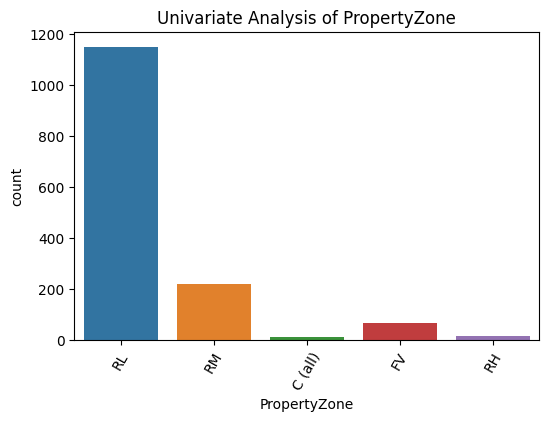

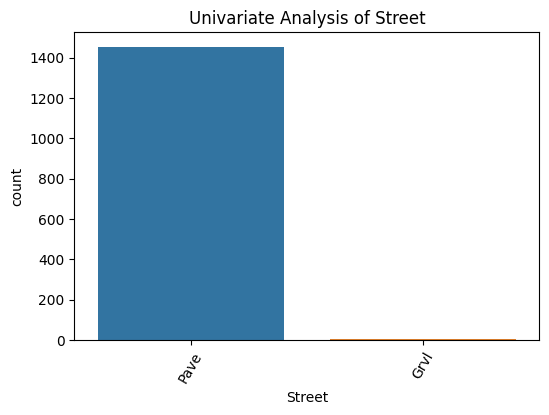

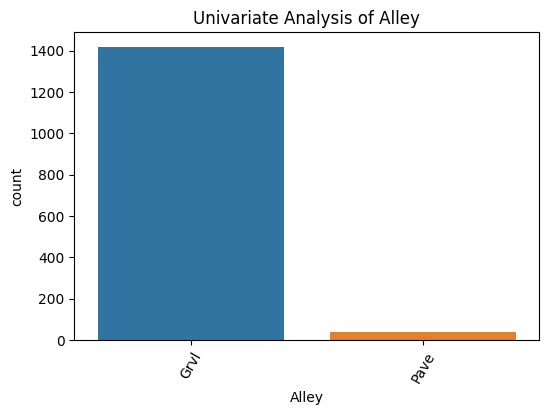

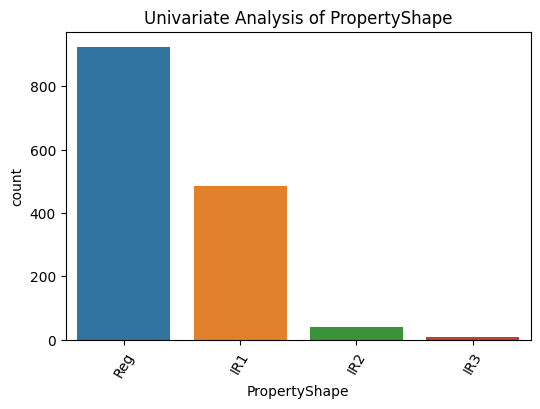

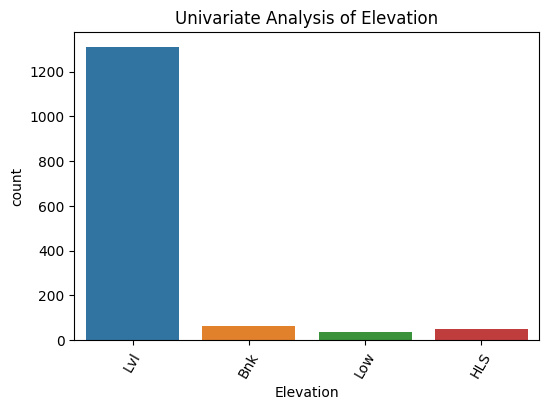

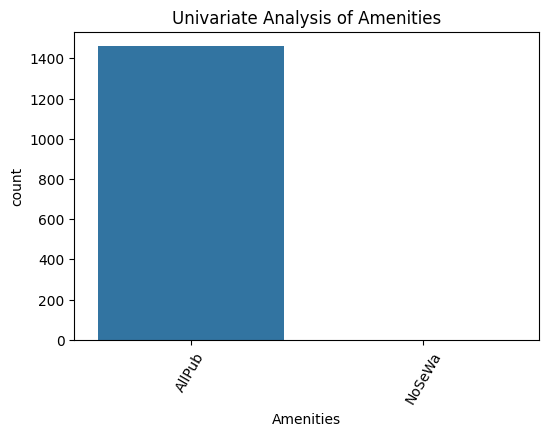

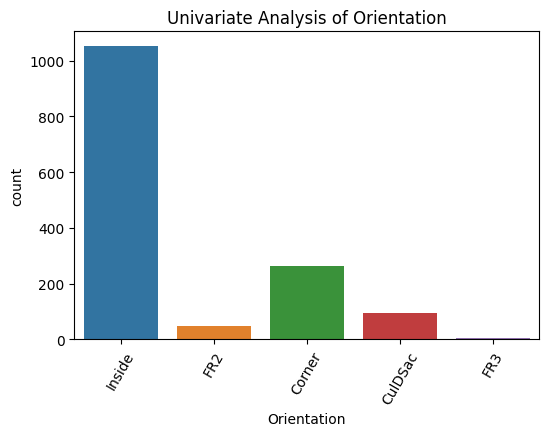

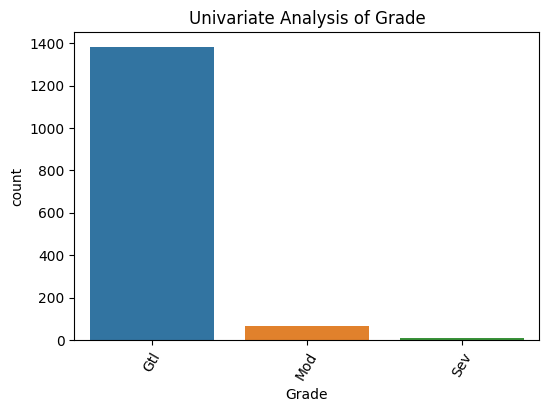

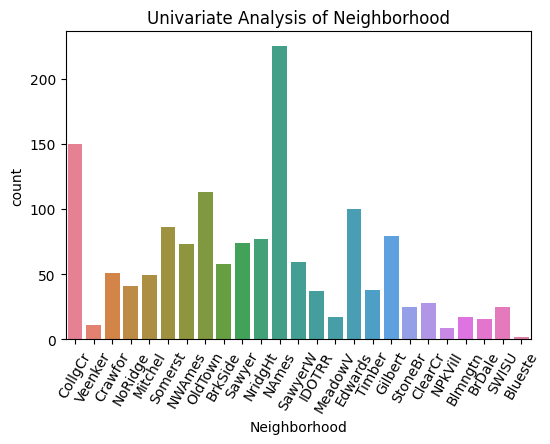

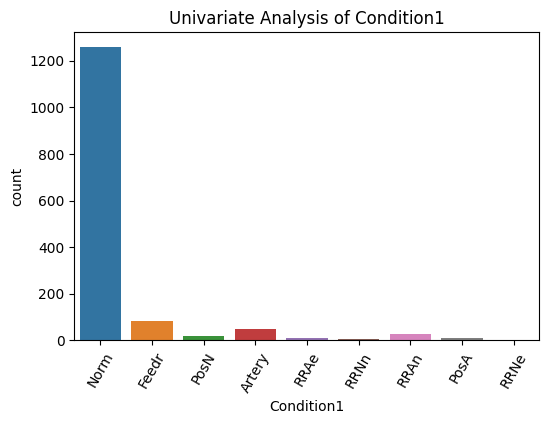

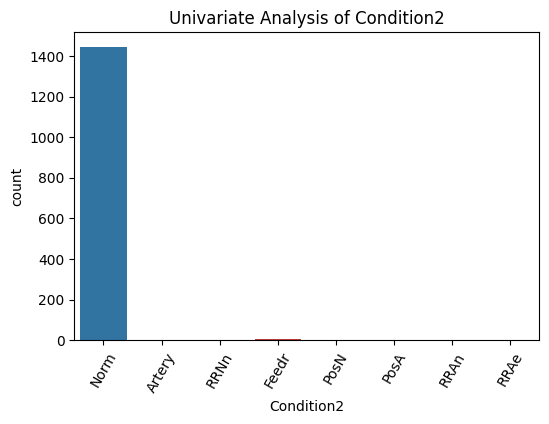

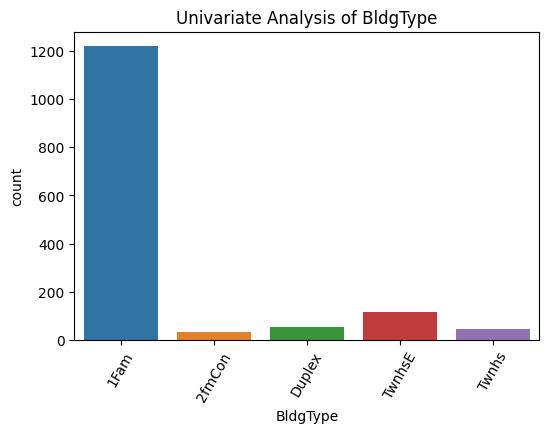

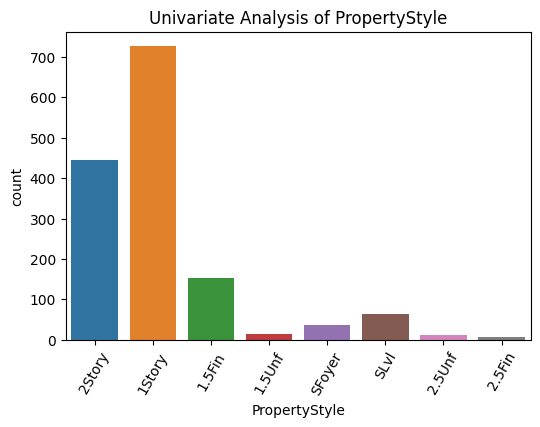

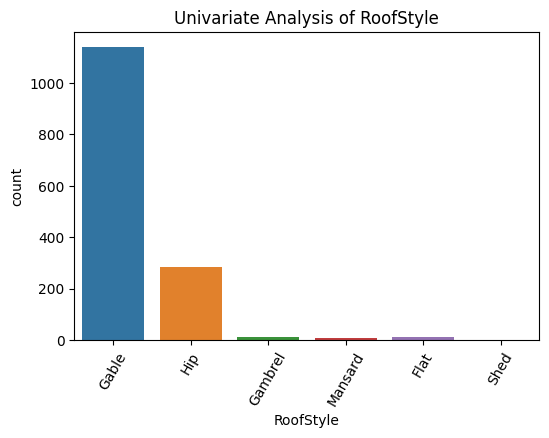

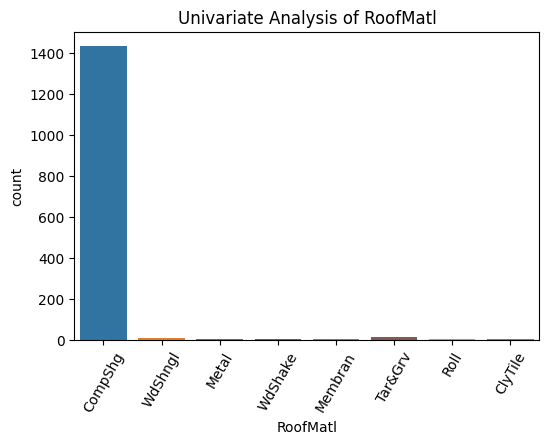

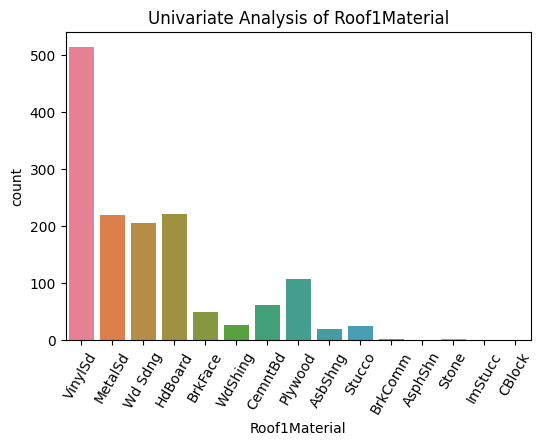

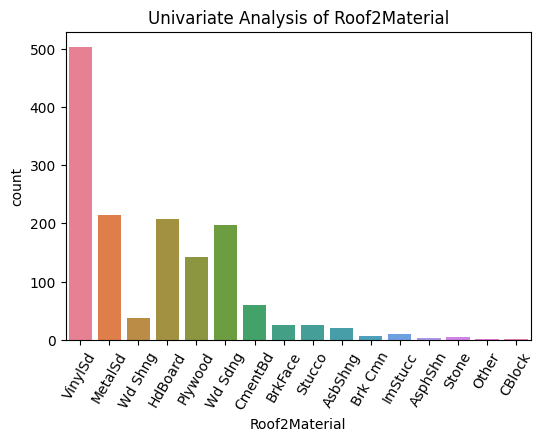

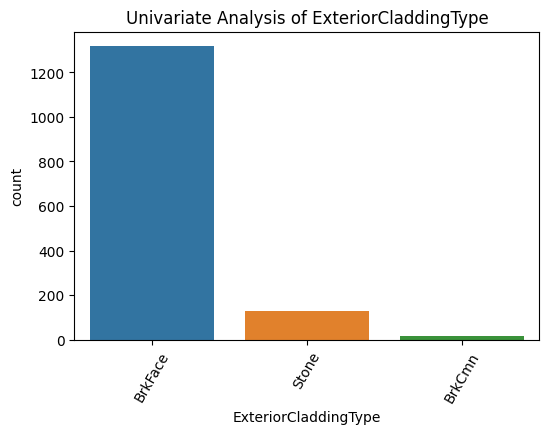

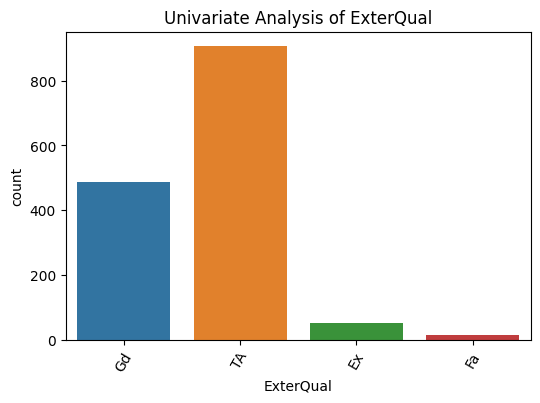

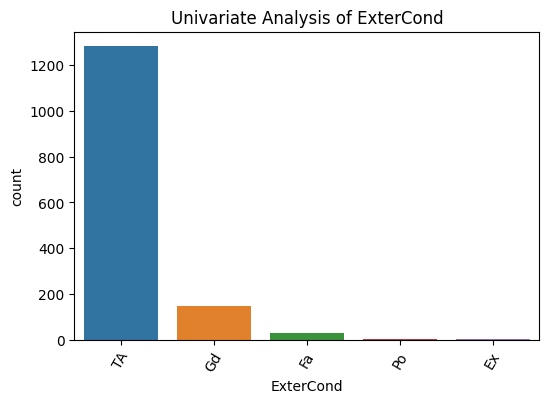

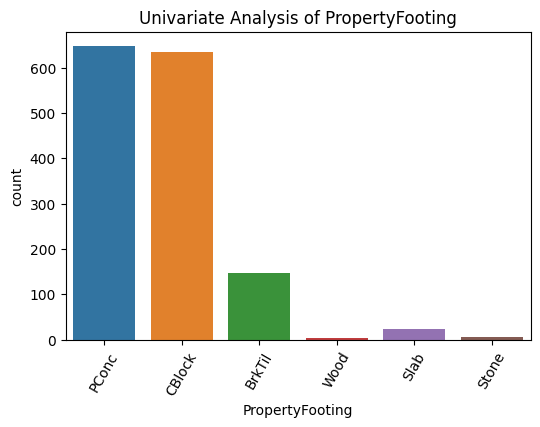

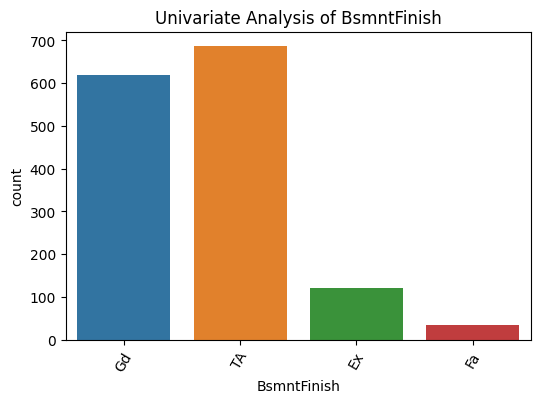

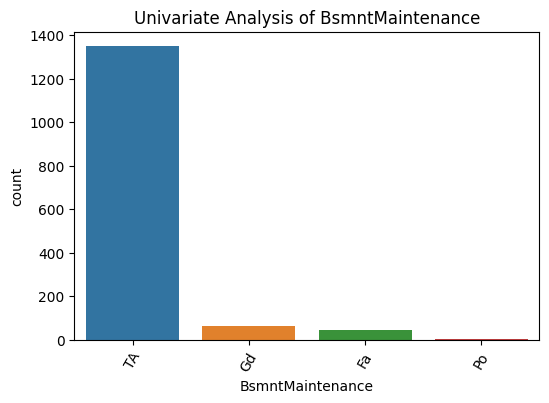

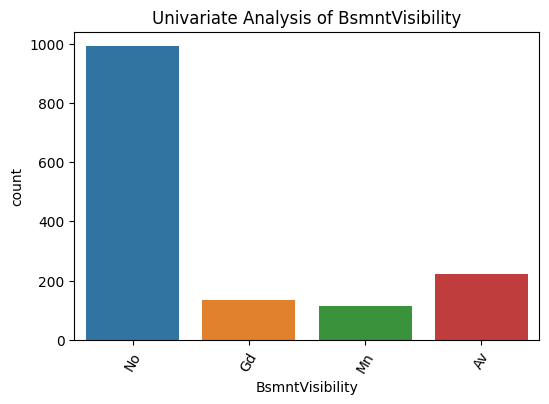

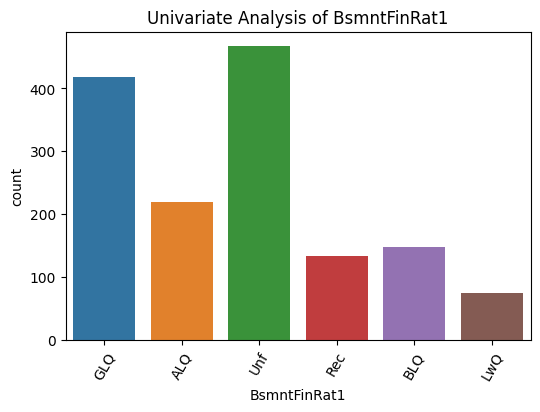

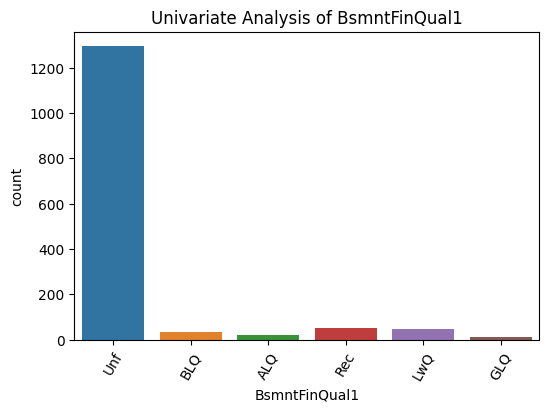

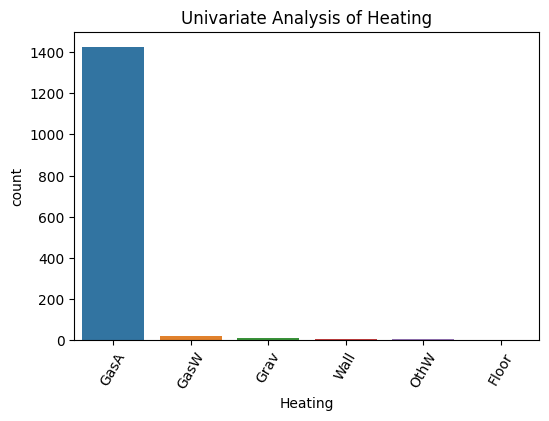

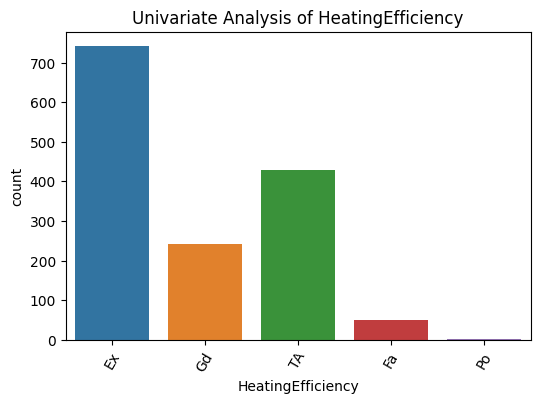

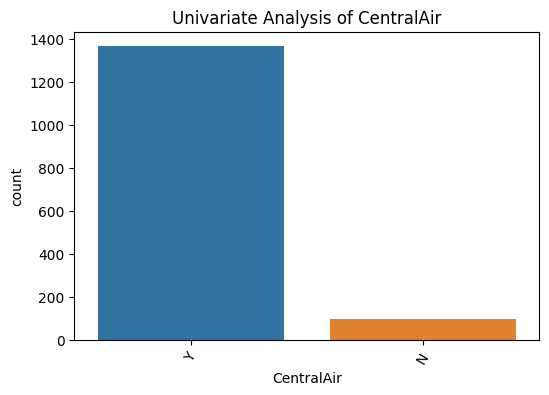

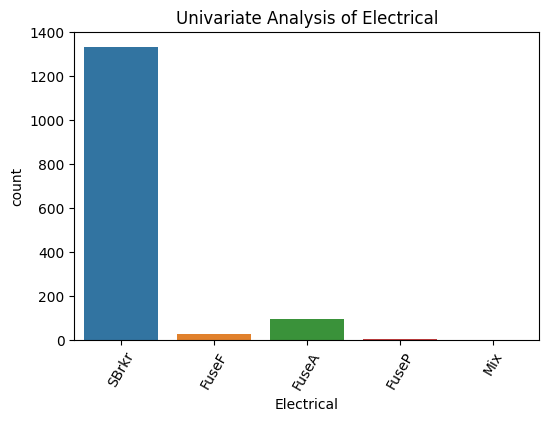

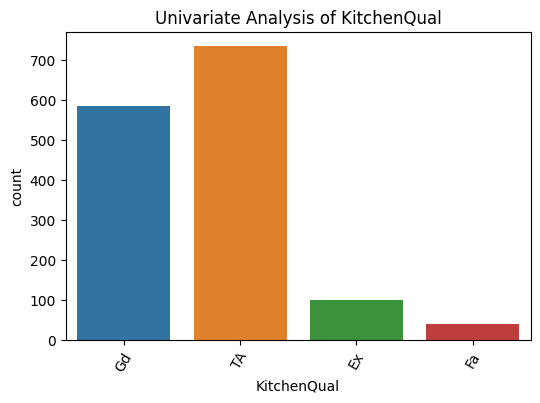

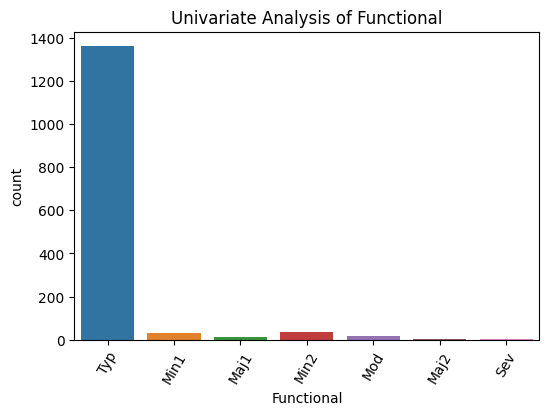

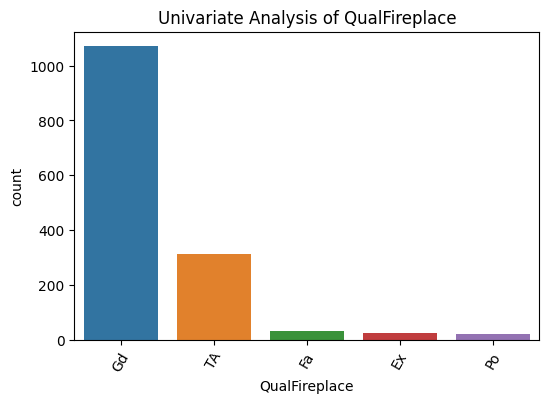

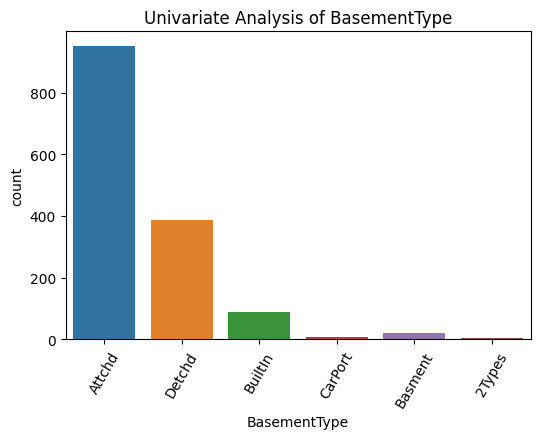

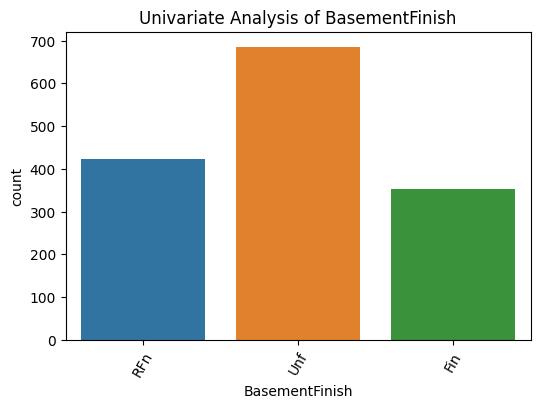

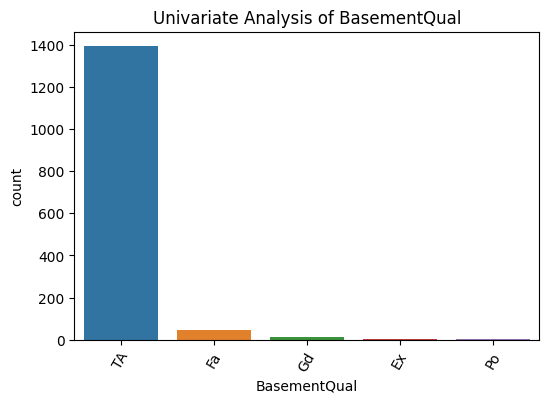

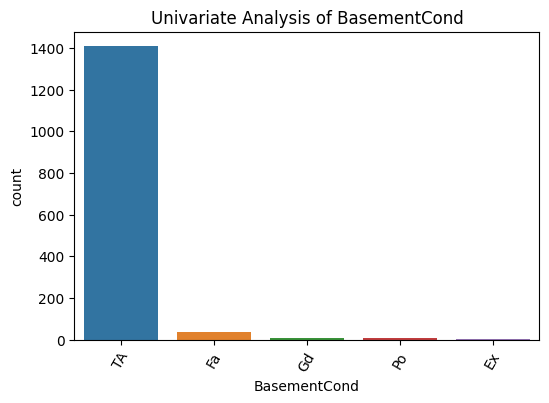

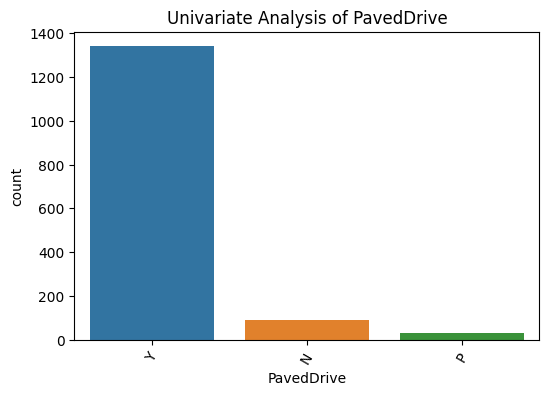

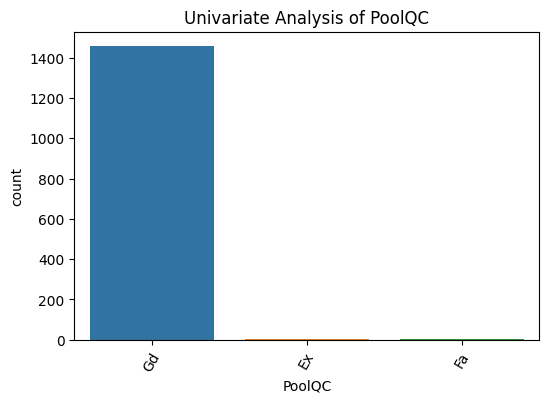

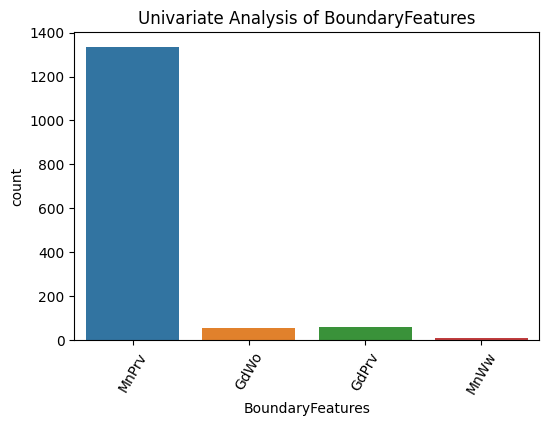

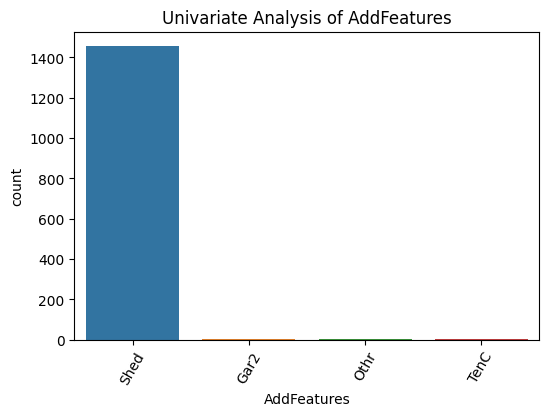

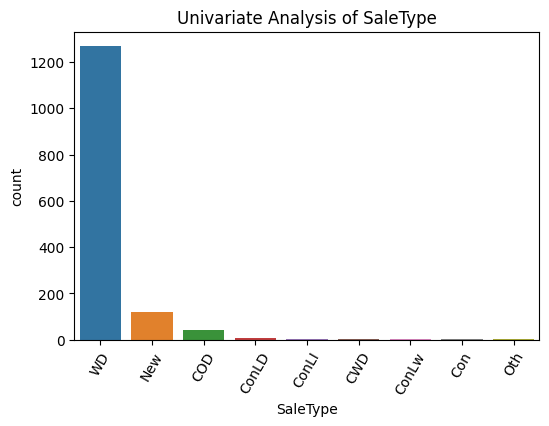

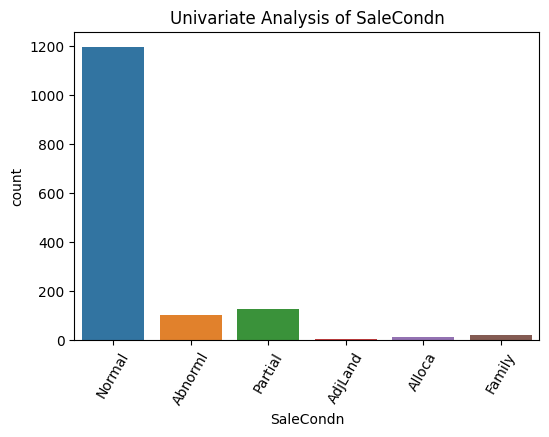

In [151]:
for c in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=c, data=df, hue=c)
    plt.title(f"Univariate Analysis of {c}")
    plt.xticks(rotation=60)
    plt.show()

 #### 1. PropertyZone
 ##### Observed Pattern: Strong dominance of RL zone.
 ##### Unusual Observations: Commercial or high-density zones are rare.
 ##### Insights: Dataset largely reflects low-density suburban residential properties.

 #### 2. Street
 ##### Observed Pattern: Majority paved roads.
 ##### Unusual Observations: Very few gravel roads.
 ##### Insights: Good road infrastructure is standard and expected.

 #### 3. Alley
 ##### Observed Pattern: High missing values.
 ##### Unusual Observations: Very few recorded alley types.
 ##### Insights: Missing values indicate absence of alley access.

 #### 4. PropertyShape
 ##### Observed Pattern: Regular plots dominate.
 ##### Unusual Observations: Irregular shapes occur less frequently.
 ##### Insights: Regular-shaped plots are preferred for construction and planning.

 #### 5. Elevation
 ##### Observed Pattern: Mostly level properties.
 ##### Unusual Observations: Few extreme elevation types.
 ##### Insights: Level land is easier to build on and more desirable.

 #### 6. Amenities
 ##### Observed Pattern: Most properties have full public utilities.
 ##### Unusual Observations: Limited cases with partial utilities.
 ##### Insights: Basic amenities are standard expectations in residential housing.

 #### 7. Orientation
 ##### Observed Pattern: Even distribution across orientations.
 ##### Unusual Observations: No extreme dominance.
 ##### Insights: Orientation affects sunlight and ventilation preferences.

 #### 8. Grade
 ##### Observed Pattern: Mid-level grades dominate.
 ##### Unusual Observations: Very high or low grades are rare.
 ##### Insights: Construction quality is generally average to good.

 #### 9. Neighborhood
 ##### Observed Pattern: Many categories with uneven frequency.
 ##### Unusual Observations: Few neighborhoods dominate transactions.
 ##### Insights: Location significantly influences desirability and pricing.

 #### 10. Condition1 / Condition2
 ##### Observed Pattern: Normal conditions dominate.
 ##### Unusual Observations: Very few adverse conditions.
 ##### Insights: Most properties are in standard environmental conditions.

 #### 11. BldgType
 ##### Observed Pattern: Single-family homes dominate.
 ##### Unusual Observations: Multi-unit buildings are limited.
 ##### Insights: Dataset is primarily focused on individual residential houses.

 #### 12. PropertyStyle
 ##### Observed Pattern: Few popular architectural styles dominate.
 ##### Unusual Observations: Rare styles appear infrequently.
 ##### Insights: Traditional house styles are more common and market-preferred.

 #### 13. RoofStyle / RoofMatl / Roof1Material / Roof2Material
 ##### Observed Pattern: One or two materials dominate.
 ##### Unusual Observations: Rare roofing materials.
 ##### Insights: Standard roofing is common due to cost and durability.

 #### 14. ExteriorCladdingType
 ##### Observed Pattern: High missing values.
 ##### Unusual Observations: Limited recorded cladding types.
 ##### Insights: Cladding is optional; absence is common.

 #### 15. ExterQual / ExterCond
 ##### Observed Pattern: Mostly average to good ratings.
 ##### Unusual Observations: Poor exterior quality is rare.
 ##### Insights: Exterior appearance strongly influences buyer perception.

 #### 16. PropertyFooting
 ##### Observed Pattern: Few foundation types dominate.
 ##### Unusual Observations: Rare foundation styles.
 ##### Insights: Foundation type impacts durability and long-term value.

 #### 17. BsmntFinish / BsmntMaintenance / BsmntVisibility / BsmntFinQual1 / BasementQual / BasementCond
 ##### Observed Pattern: Mostly average to good categories.
 ##### Unusual Observations: High missing indicates no basement.
 ##### Insights: Finished and well-maintained basements add usable living space. 

 #### 18. Heating / HeatingEfficiency
 ##### Observed Pattern: Standard heating systems dominate.
 ##### Unusual Observations: Few inefficient systems.
 ##### Insights: Efficient heating reduces operating costs.

 #### 19. CentralAir
 ##### Observed Pattern: Majority have central air.
 ##### Unusual Observations: Few properties lack it.
 ##### Insights: Central air is a standard expectation.

 #### 20. Electrical
 ##### Observed Pattern: Modern electrical systems dominate.
 ##### Unusual Observations: Very few outdated systems.
 ##### Insights: Electrical safety and capacity affect livability.

 #### 21. KitchenUpLev, KitchenQual
 ##### Observed Pattern: Mostly average to good quality kitchens.
 ##### Unusual Observations: Very few poor-quality kitchens.
 ##### Insights: Kitchen quality is a major selling point.

 #### 22. Functional
 ##### Observed Pattern: Fully functional layouts dominate.
 ##### Unusual Observations: Few dysfunctional properties.
 ##### Insights: Functional design is critical for marketability.

 #### 23. QualFireplace
 ##### Observed Pattern: One fireplace is common.
 ##### Unusual Observations: Many homes lack fireplaces.
 ##### Insights: Fireplaces add aesthetic and resale value.

 #### 24. PavedDrive
 ##### Observed Pattern: Mostly paved driveways.
 ##### Unusual Observations: Very few unpaved drives.
 ##### Insights: Paved access is expected in residential areas.

 #### 25. PoolQC
 ##### Observed Pattern: Many zero values.
 ##### Unusual Observations: Pools are extremely rare.
 ##### Insights: Outdoor amenities are luxury additions.

 #### 26. BoundaryFeatures / AddFeatures
 ##### Observed Pattern: Mostly absent.
 ##### Unusual Observations: Few high-value additions.
 ##### Insights: Extra features differentiate premium properties.

 #### 27. SaleType
 ##### Observed Pattern: Normal sales dominate.
 ##### Unusual Observations: Few distressed sales.
 ##### Insights: Prices largely reflect fair market value.

 #### 28. SaleCondn
 ##### Observed Pattern: Normal conditions dominate.
 ##### Unusual Observations: Abnormal sales are rare.
 ##### Insights: Most transactions are standard.

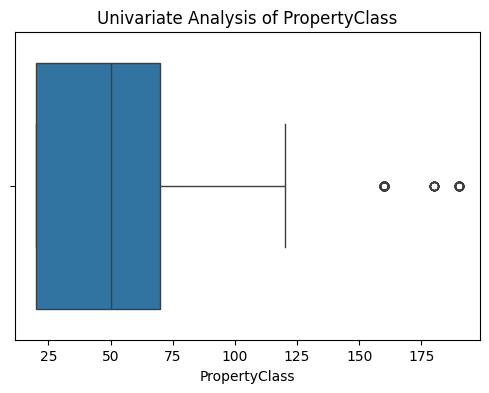

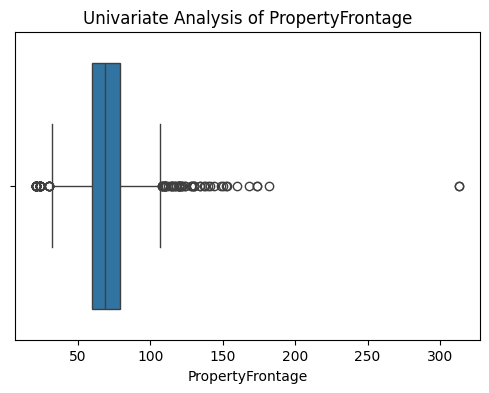

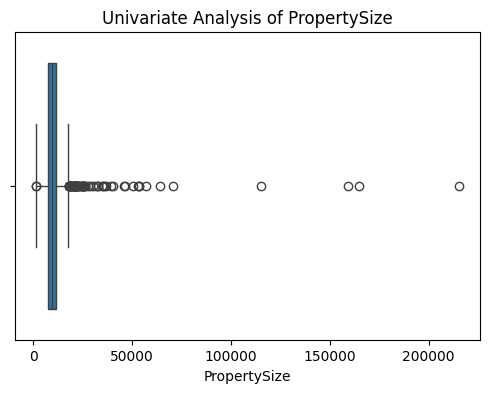

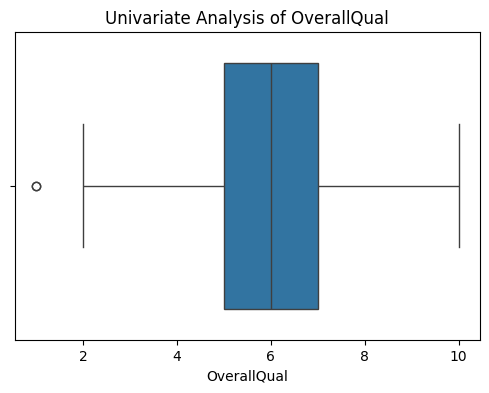

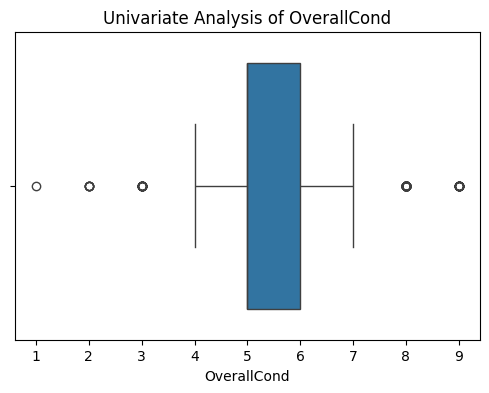

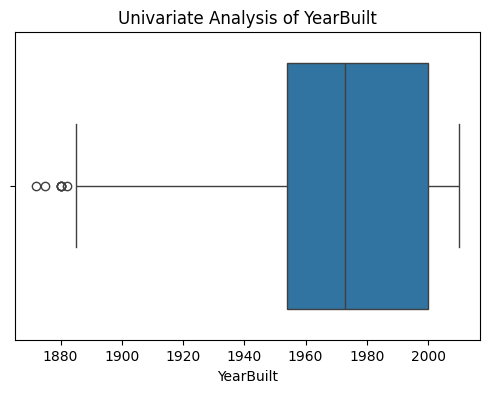

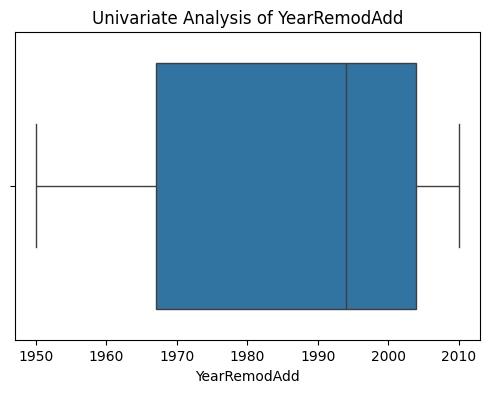

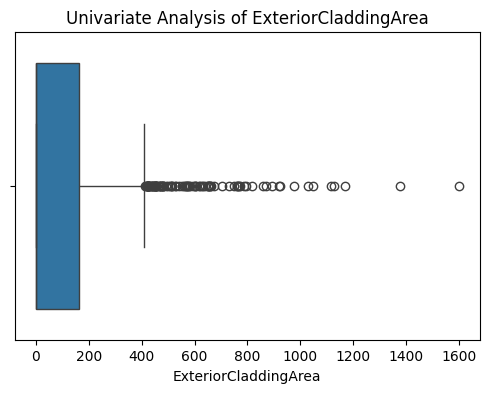

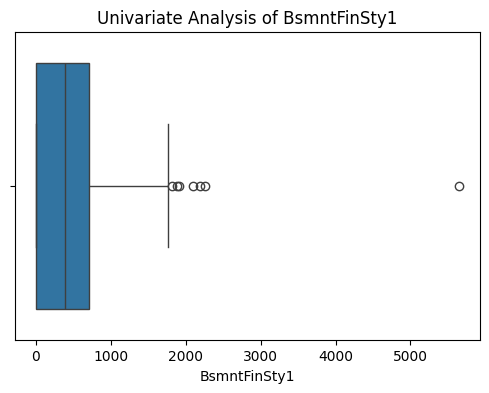

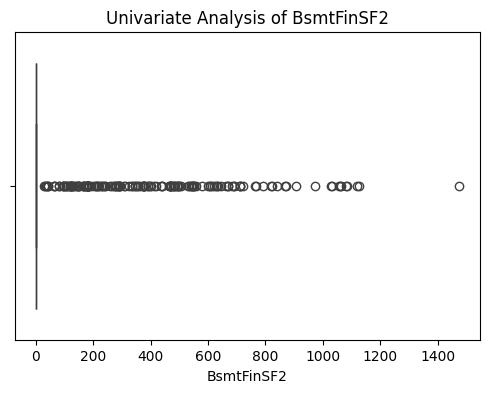

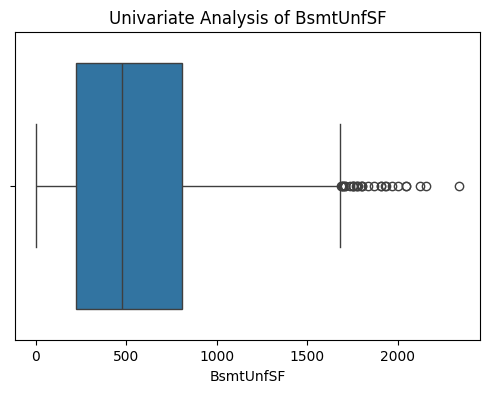

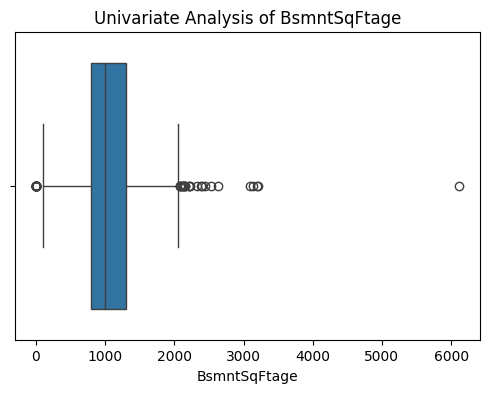

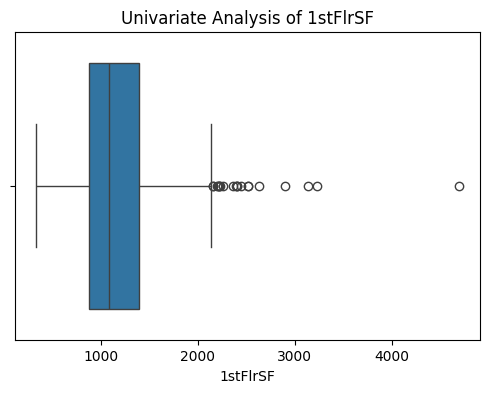

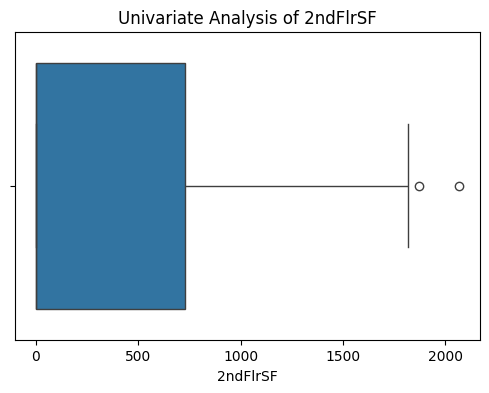

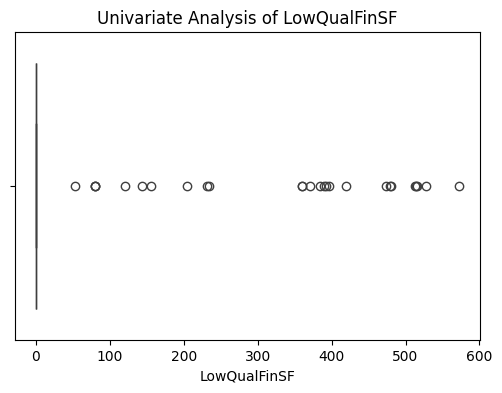

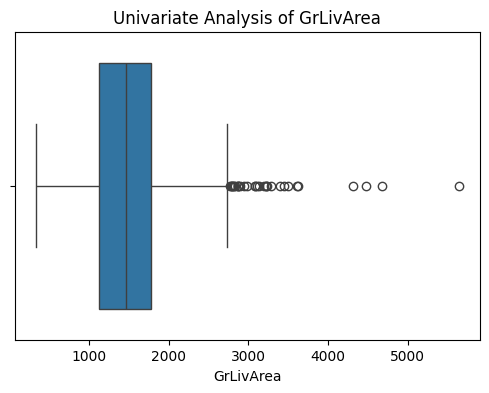

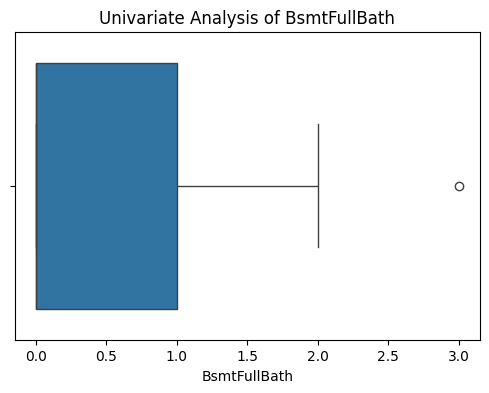

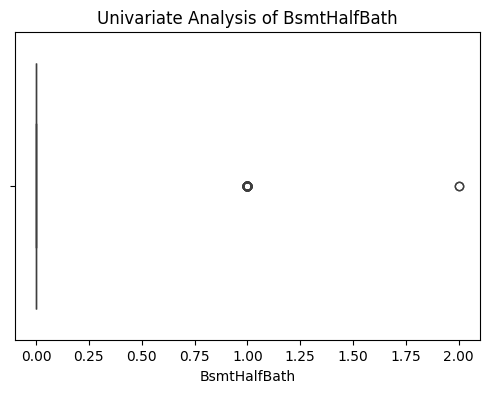

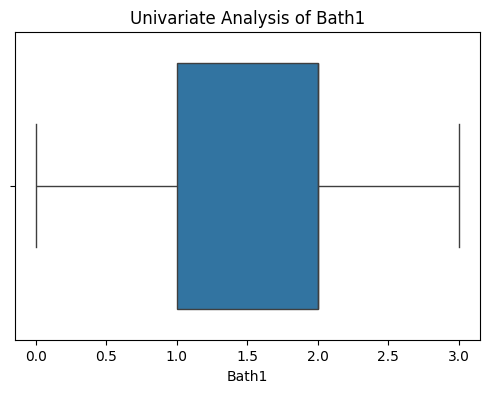

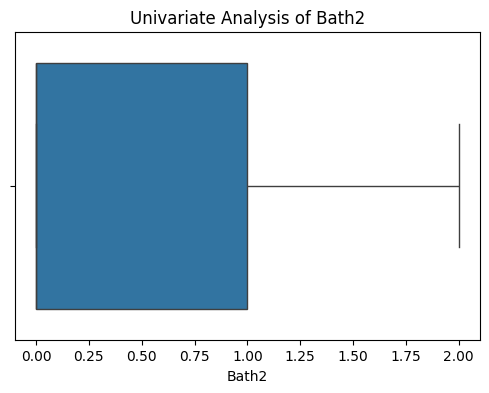

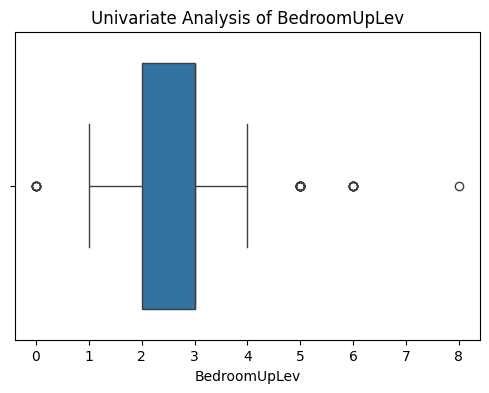

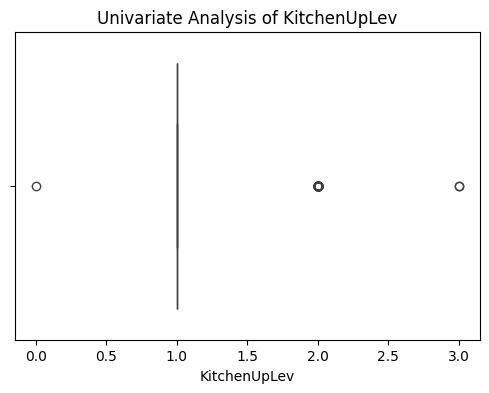

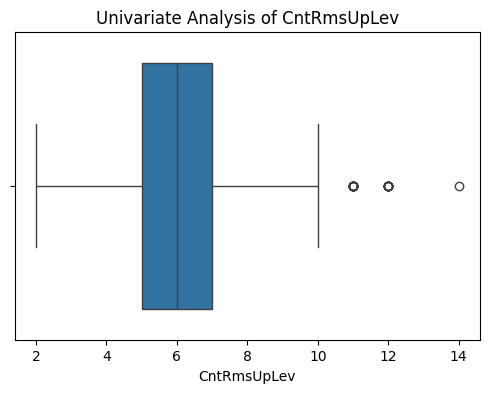

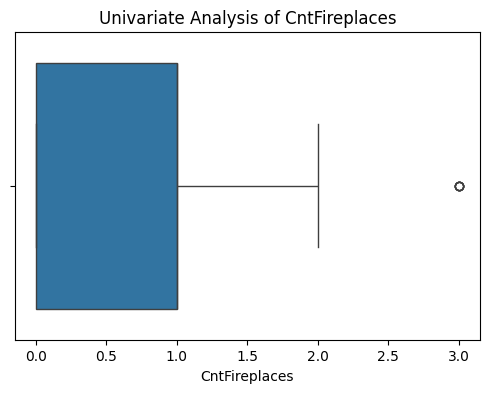

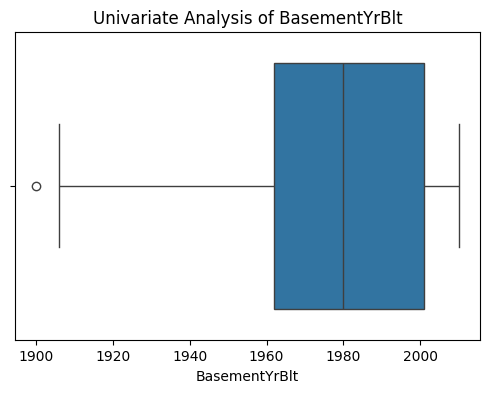

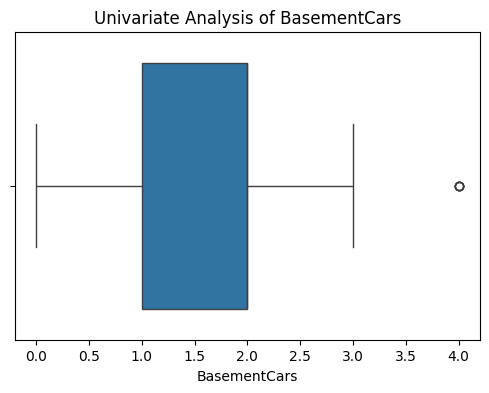

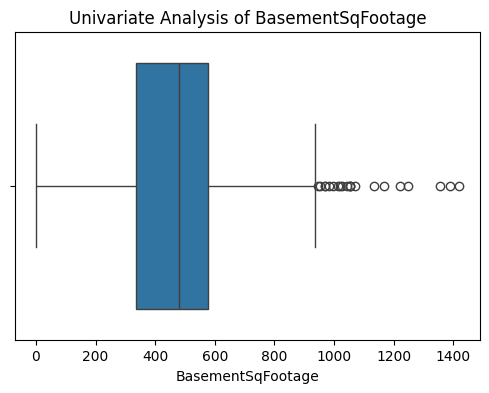

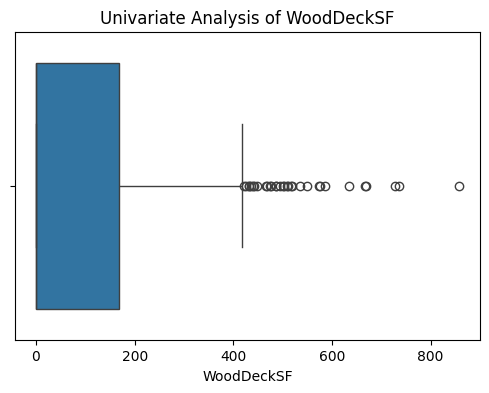

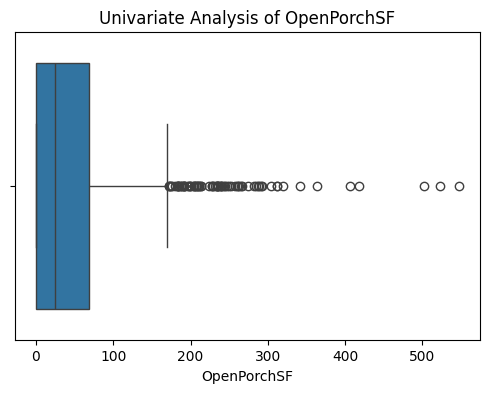

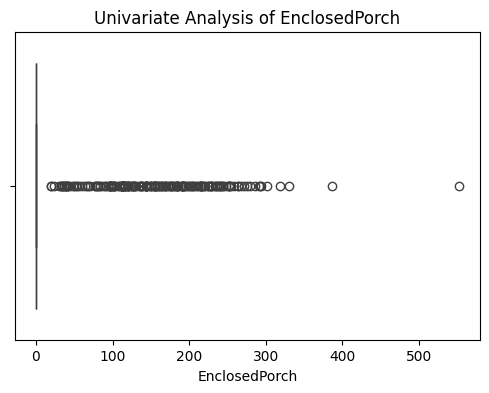

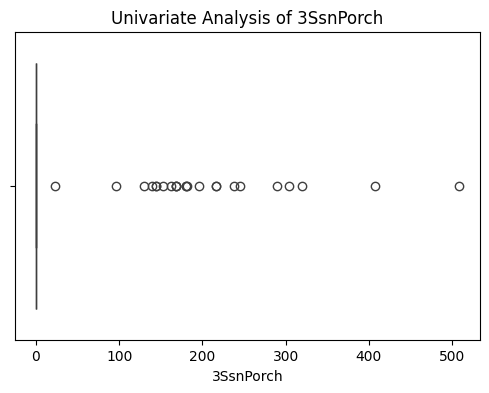

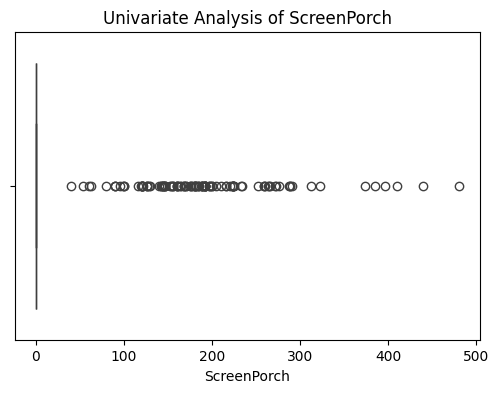

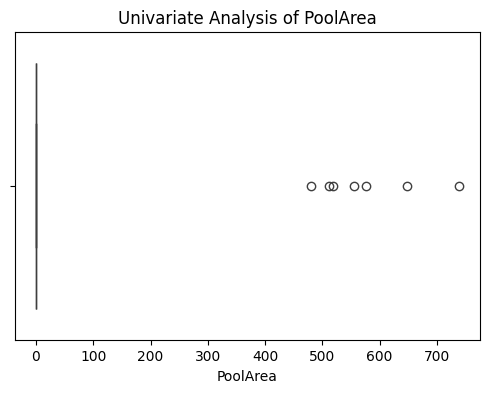

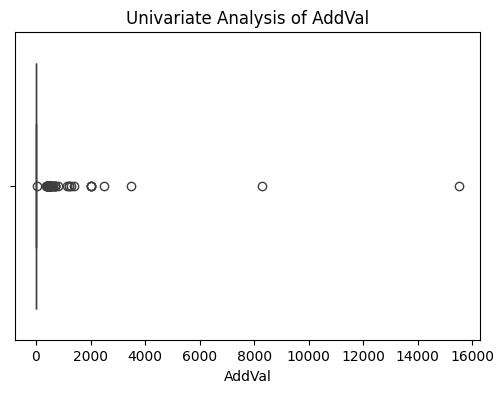

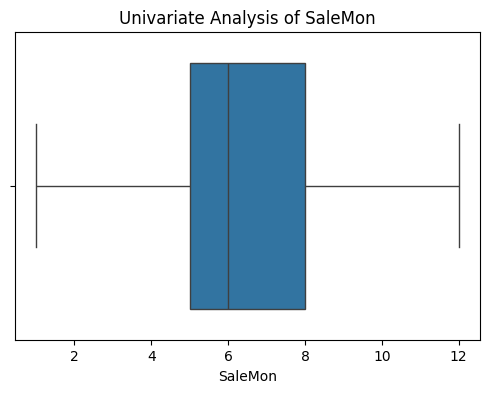

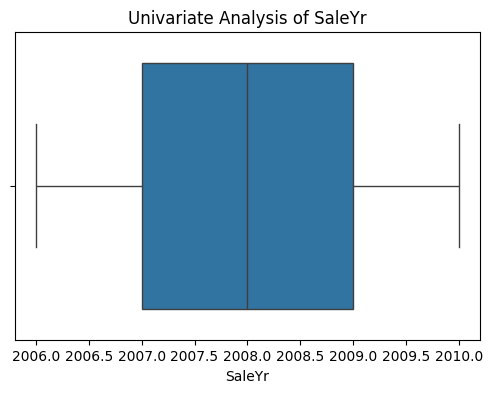

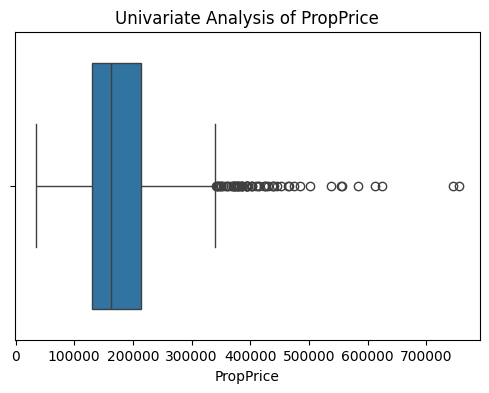

In [152]:
for c in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[c])
    plt.title(f"Univariate Analysis of {c}")
    plt.show()

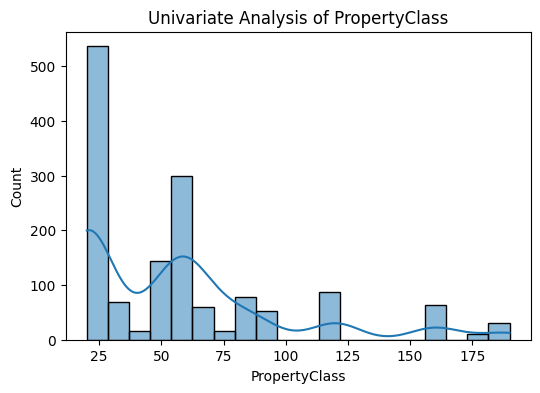

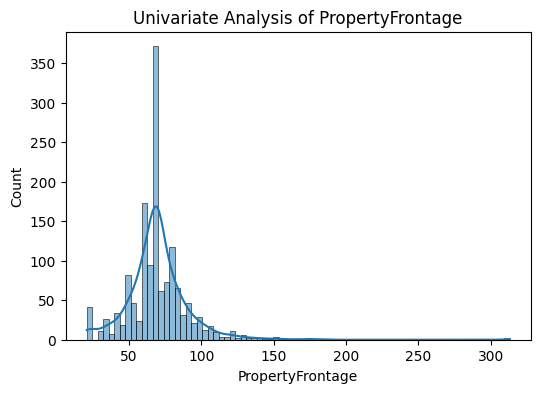

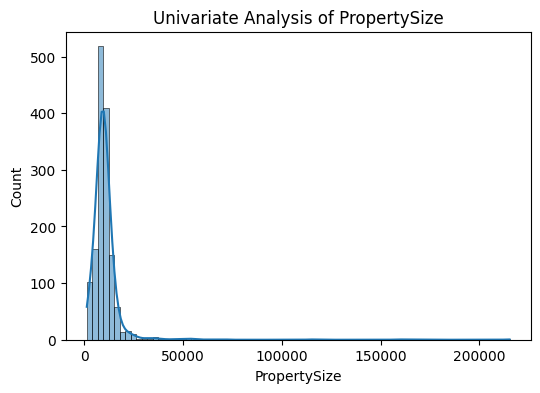

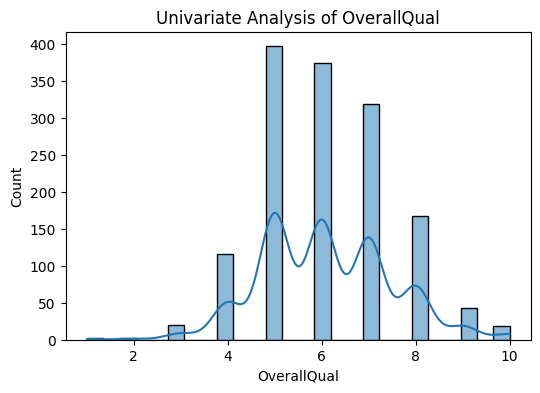

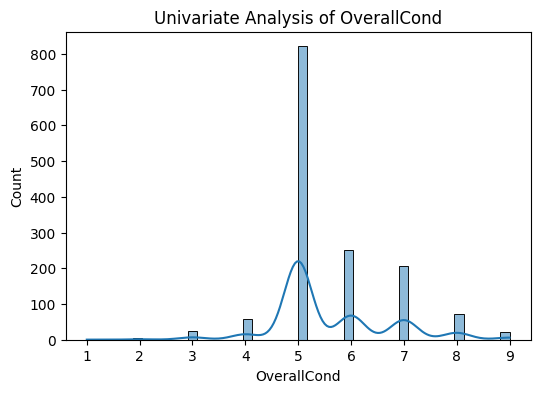

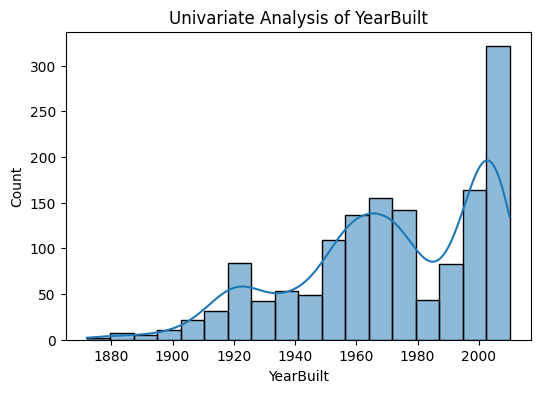

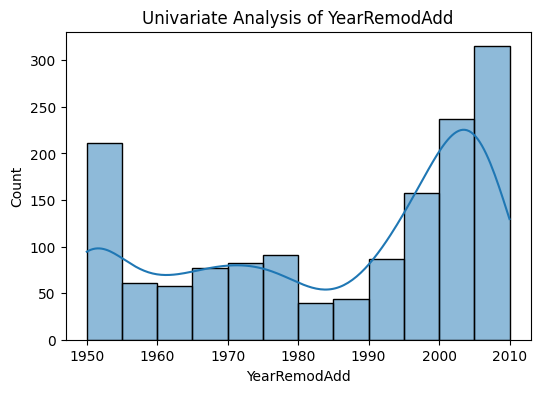

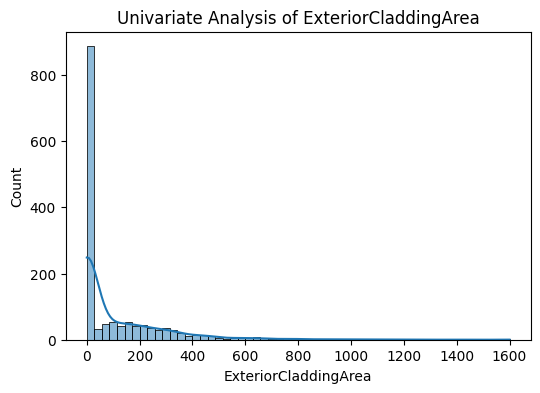

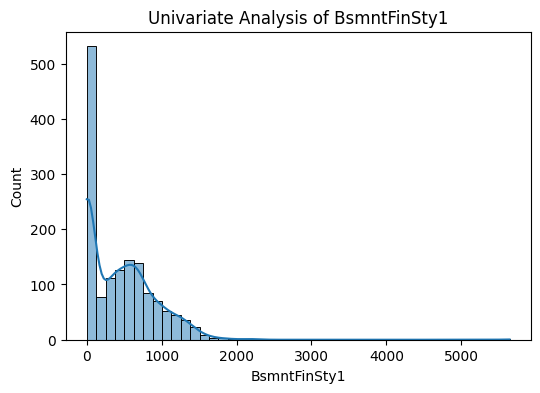

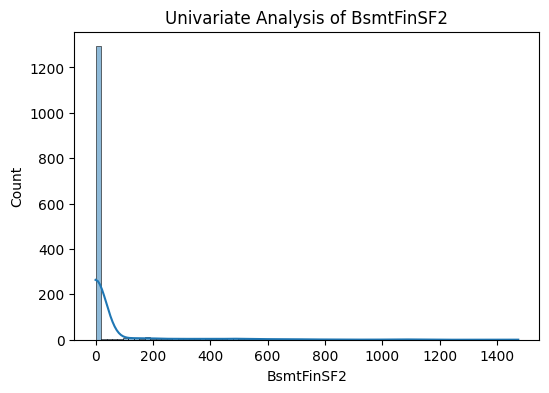

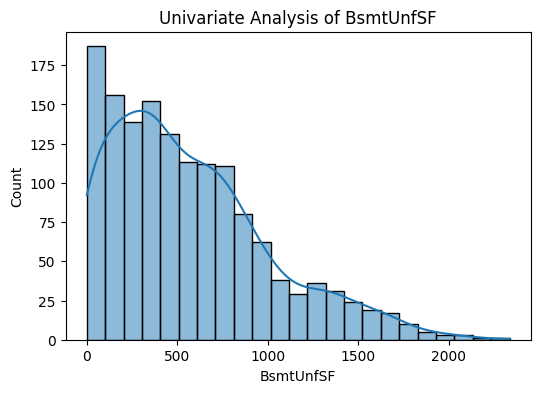

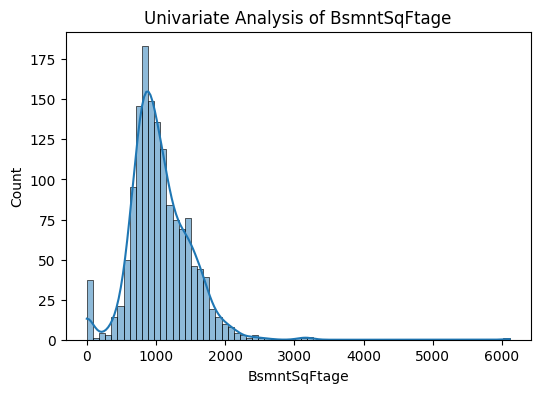

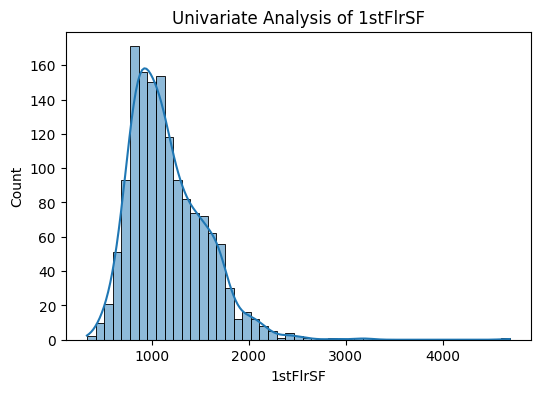

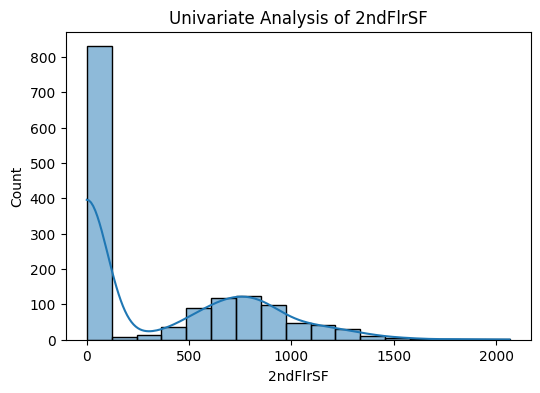

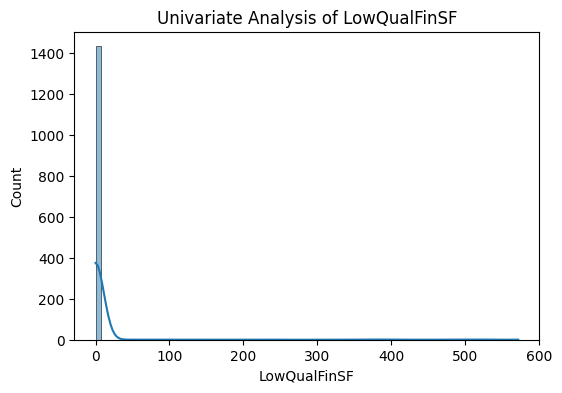

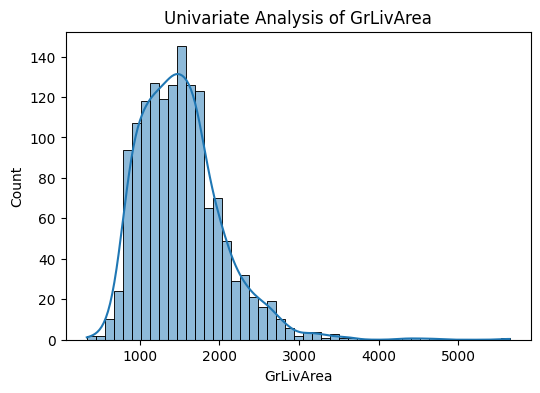

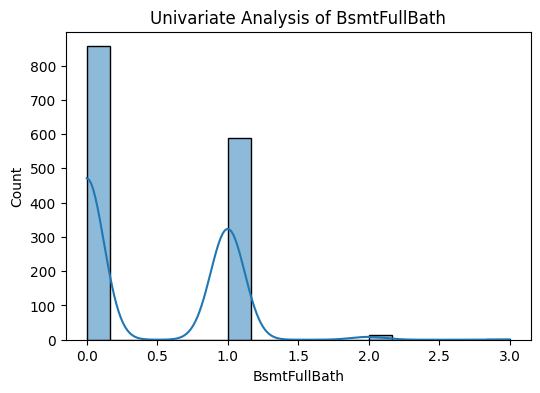

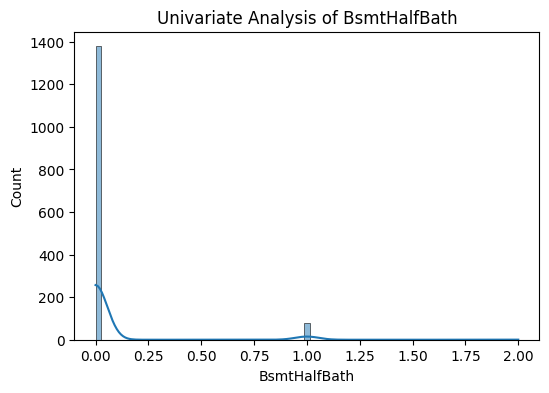

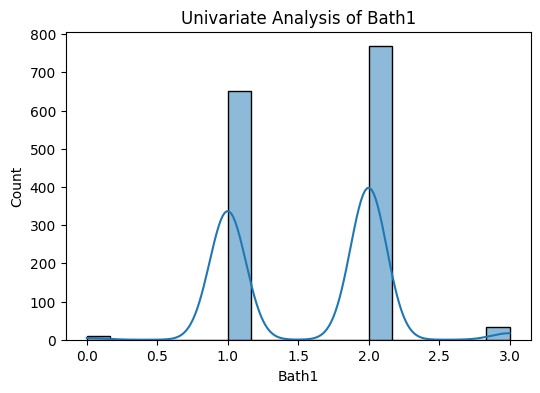

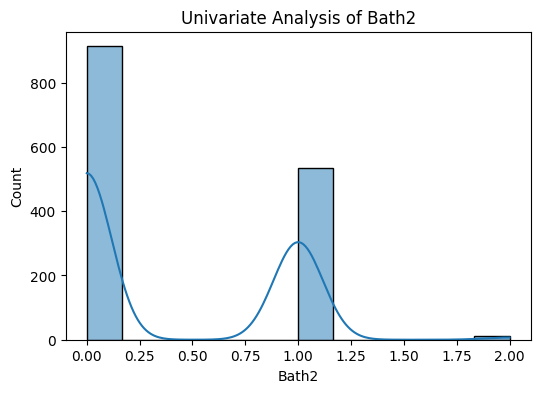

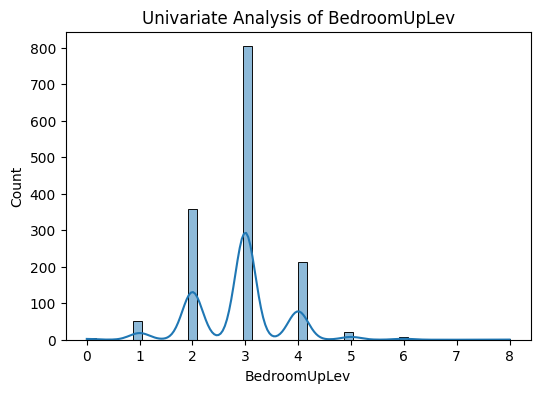

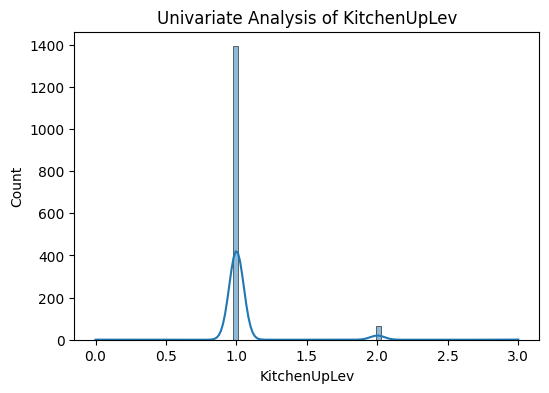

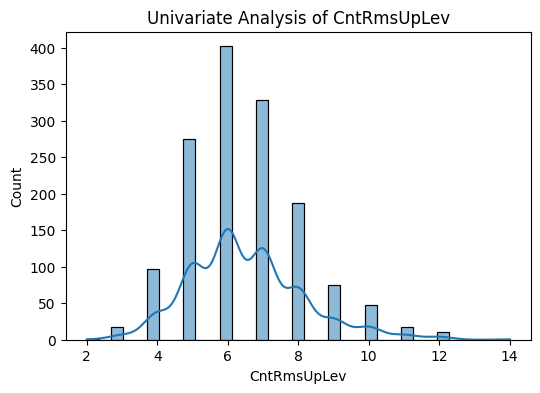

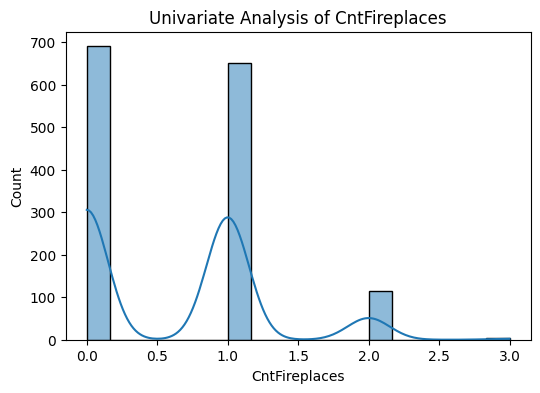

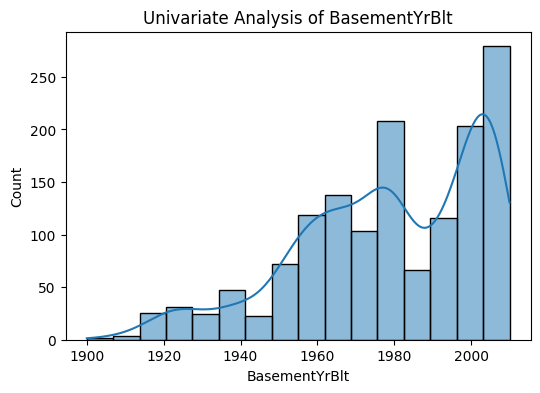

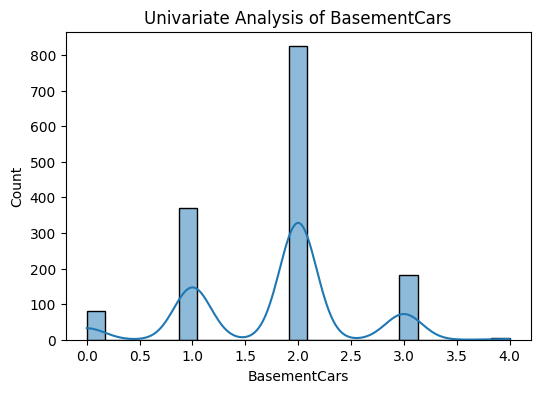

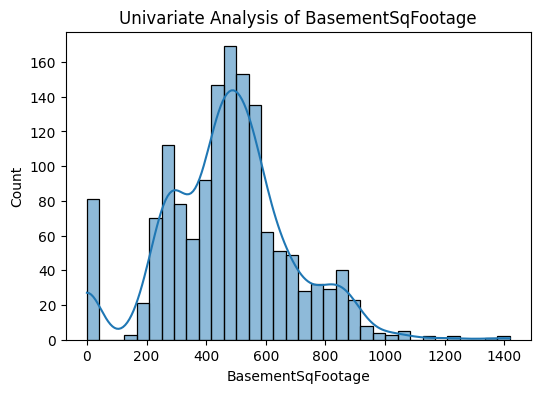

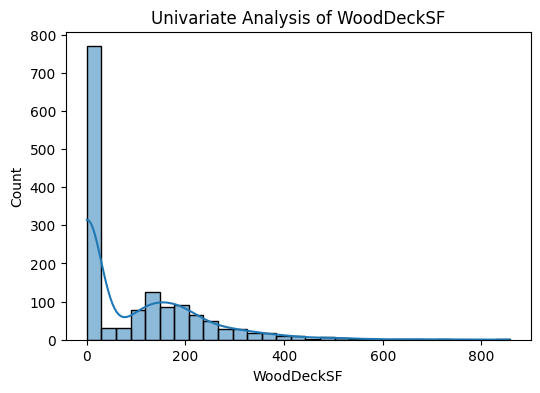

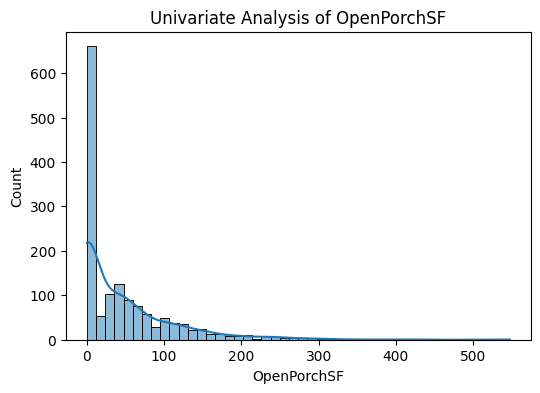

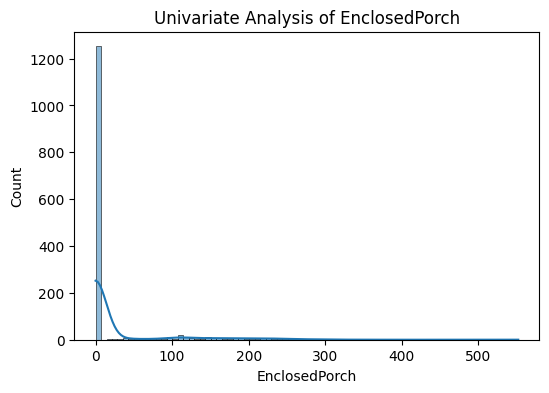

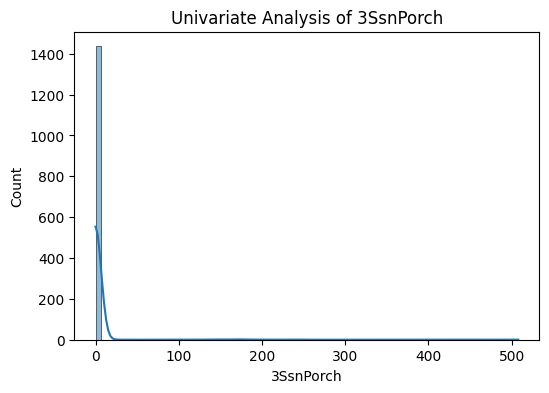

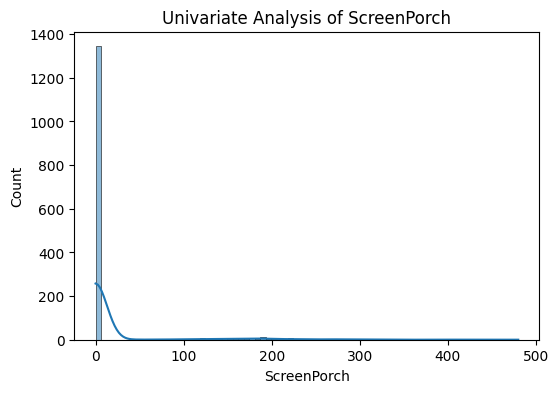

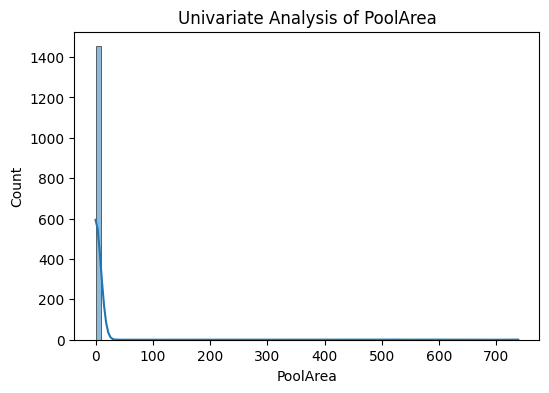

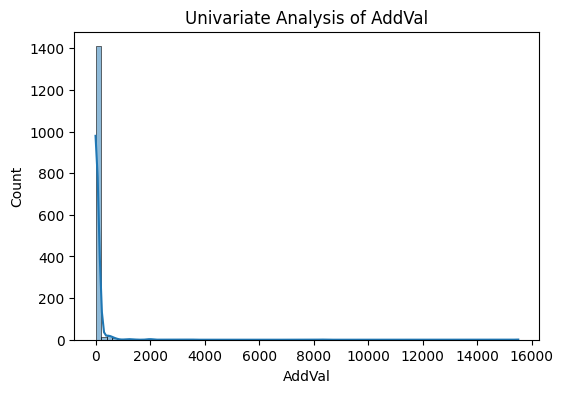

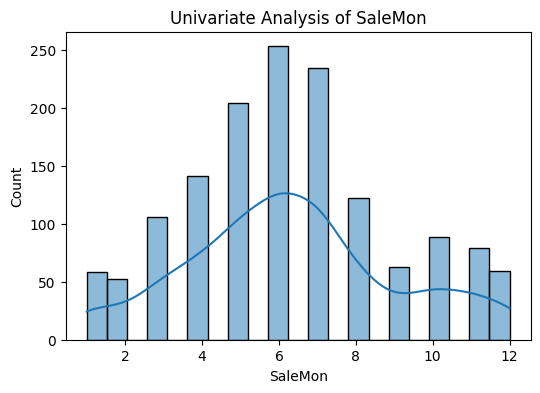

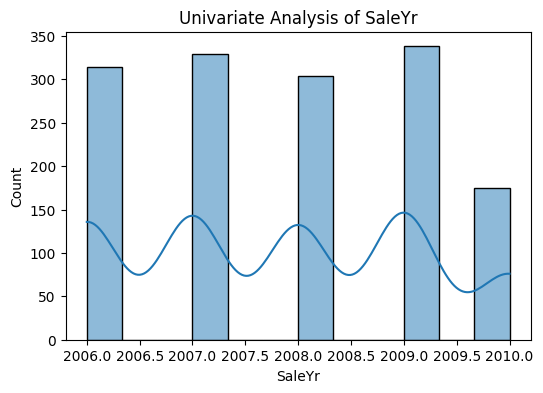

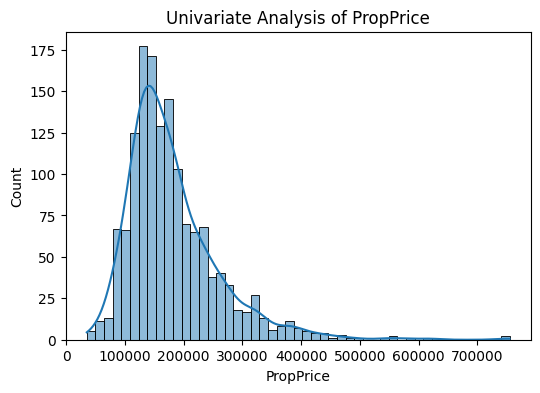

In [26]:
for c in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=c, data=df, kde=True)
    plt.title(f"Univariate Analysis of {c}")
    plt.show()

 #### 1. PropertyClass
 ##### Observed Pattern: Few discrete classes with uneven distribution.
 ##### Unusual Observations: Some classes occur very infrequently.
 ##### Insights: Property class represents construction/zoning categories; certain classes dominate residential markets.

 #### 2. PropertyFrontage
 ##### Observed Pattern: Right-skewed with wide spread.
 ##### Unusual Observations: Presence of high-value outliers.
 ##### Insights: Larger frontage often corresponds to corner or irregular plots, increasing variability.

 #### 3. PropertySize
 ##### Observed Pattern: Right-skewed distribution.
 ##### Unusual Observations: A few extremely large plots.
 ##### Insights: Larger plots generally increase property value but are less common.

 #### 4. OverallQual
 ##### Observed Pattern: Concentration around ratings 5–7.
 ##### Unusual Observations: Very few extreme ratings.
 ##### Insights: Overall quality is a major driver of property value.

 #### 5. OverallCond
 ##### Observed Pattern: Most properties rated average.
 ##### Unusual Observations: Extreme conditions are rare.
 ##### Insights: Most homes are reasonably maintained.

 #### 6. YearBuilt
 ##### Observed Pattern: Most properties built after 1960.
 ##### Unusual Observations: Few very old constructions.
 ##### Insights: Newer homes align with modern construction standards and higher value.

 #### 7. YearRemodAdd
 ##### Observed Pattern: Remodeling concentrated in recent decades.
 ##### Unusual Observations: Some properties never remodeled.
 ##### Insights: Renovations improve functionality and market value.

 #### 8. ExteriorCladdingArea
 ##### Observed Pattern: Many zero values with right skew.
 ##### Unusual Observations: Few very large cladding areas.
 ##### Insights: Larger cladding areas reflect premium finishes.

 #### 9. BsmntFinSty1 / BsmtFinSF2 / BsmtUnfSF / BsmntSqFtage
 ##### Observed Pattern: Right-skewed distributions.
 ##### Unusual Observations: Some properties have zero basement area.
 ##### Insights: Basement size contributes to overall usable space.

 #### 10. 1stFlrSF / 2ndFlrSF / GrLivArea
 ##### Observed Pattern: Right-skewed with clustering at lower values.
 ##### Unusual Observations: Very large houses form outliers.
 ##### Insights: Total living area is a key price determinant.

 #### 11. LowQualFinSF
 ##### Observed Pattern: Mostly zero values.
 ##### Unusual Observations: Few non-zero cases.
 ##### Insights: Low-quality finished space adds limited value.

 #### 12. BsmtFullBath / BsmtHalfBath / Bath1 / Bath2 / BedroomUpLev / CntRmsUpLev
 ##### Observed Pattern: Typical family-sized configurations dominate.
 ##### Unusual Observations: Extreme counts are rare.
 ##### Insights: More rooms and bathrooms increase comfort and value.

 #### 13. KitchenUpLev
 ##### Observed Pattern: Mostly average to good quality kitchens.
 ##### Unusual Observations: Very few poor-quality kitchens.
 ##### Insights: Kitchen quality is a major selling point.

 #### 14. CntFireplaces
 ##### Observed Pattern: One fireplace is common.
 ##### Unusual Observations: Many homes lack fireplaces.
 ##### Insights: Fireplaces add aesthetic and resale value.

 #### 15. BasementCars / BasementSqFootage
 ##### Observed Pattern: Two-car parking is most common.
 ##### Unusual Observations: Few properties without parking.
 ##### Insights: Parking availability is essential for buyers.

 #### 16. WoodDeckSF / OpenPorchSF / EnclosedPorch / 3SsnPorch / ScreenPorch / PoolArea
 ##### Observed Pattern: Many zero values.
 ##### Unusual Observations: Pools are extremely rare.
 ##### Insights: Outdoor amenities are luxury additions.

 #### 17. AddVal
 ##### Observed Pattern: Mostly absent.
 ##### Unusual Observations: Few high-value additions.
 ##### Insights: Extra features differentiate premium properties.

 #### 18. SaleMon
 ##### Observed Pattern: Sales peak mid-year.
 ##### Unusual Observations: Lower winter activity.
 ##### Insights: Property sales show seasonality.

 #### 19. SaleYr
 ##### Observed Pattern: Concentrated in recent years.
 ##### Unusual Observations: Limited early-year sales.
 ##### Insights: Reflects market conditions over time.

 #### 20. PropPrice
 ##### Observed Pattern: Highly right-skewed.
 ##### Unusual Observations: Luxury property outliers.
 ##### Insights: Real estate prices vary widely; median better represents typical market value.

 ### b) Bivariate Analysis(Major Plots):

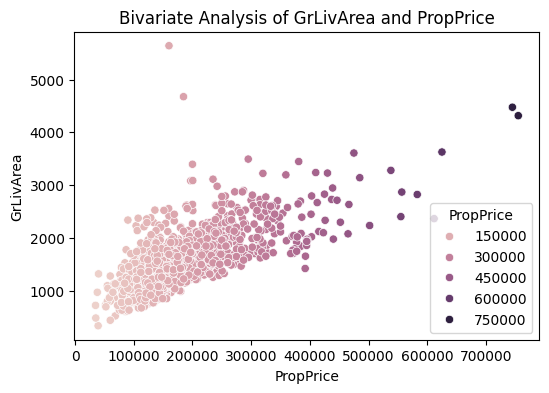

In [67]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='PropPrice', y='GrLivArea', data=df, hue=c)
plt.title(f"Bivariate Analysis of GrLivArea and PropPrice")
plt.show()

 #### Insights for GrLivArea vs PropPrice: 
 ##### Here observed the clear upward trend more spread at higher values which shows that as the living area increases, property price increases significantly, indicating a strong positive correlation. Larger homes tend to command higher prices, though variability increases for luxury properties.

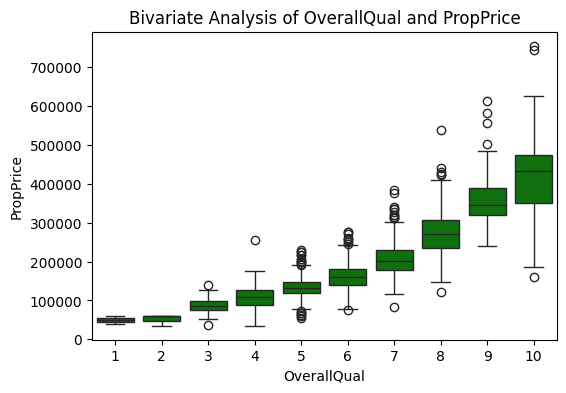

In [116]:
plt.figure(figsize=(6,4))
sns.boxplot(y='PropPrice', x='OverallQual', data=df, color='Green')
plt.title(f"Bivariate Analysis of OverallQual and PropPrice")
plt.show()

 #### Insights for OverallQual vs PropPrice:
 ##### Here observed that the median price rises steadily from low to high quality and Spread increases at higher quality levels which shows the properties with higher overall quality ratings consistently show higher median prices, confirming overall quality as one of the strongest determinants of property value.

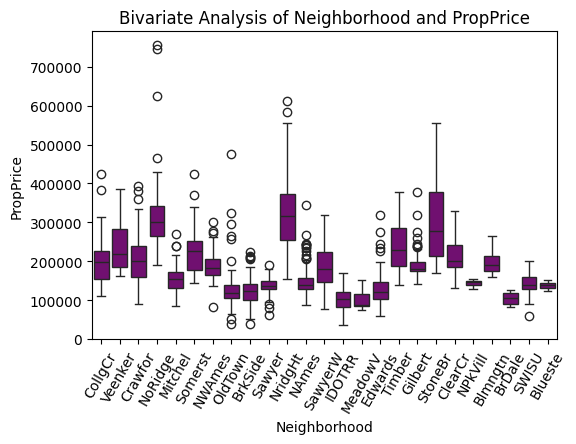

In [108]:
plt.figure(figsize=(6,4))
sns.boxplot(y='PropPrice', x='Neighborhood', data=df, color='Purple')
plt.title(f"Bivariate Analysis of Neighborhood and PropPrice")
plt.xticks(rotation=60)
plt.show()

 #### Insights for Neighborhood vs PropPrice:
 ##### Here observed some neighborhoods have much higher medians and strong inter-neighborhood variation which shows the property prices vary significantly across neighborhoods, highlighting the importance of location in determining market value.

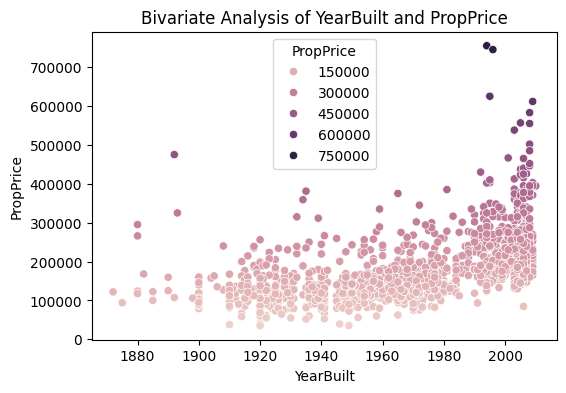

In [113]:
plt.figure(figsize=(6,4))
sns.scatterplot(y='PropPrice', x='YearBuilt', data=df, hue=c)
plt.title(f"Bivariate Analysis of YearBuilt and PropPrice")
plt.show()

 #### Insights for YearBuilt vs PropPrice:
 ##### Here observed newer houses generally have higher prices some old houses still expensive which shows newer properties tend to sell at higher prices due to modern construction standards, though location and renovations allow some older homes to retain high value.

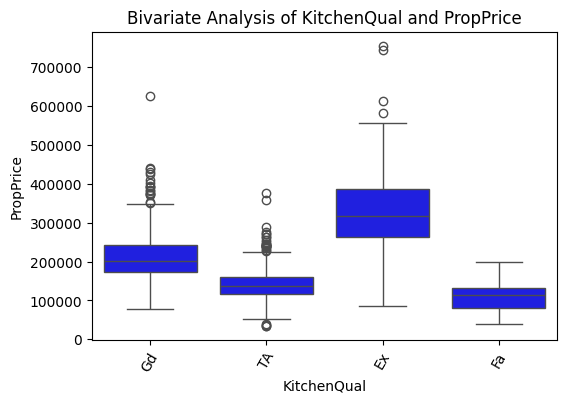

In [115]:
plt.figure(figsize=(6,4))
sns.boxplot(y='PropPrice', x='KitchenQual', data=df, color='Blue')
plt.title(f"Bivariate Analysis of KitchenQual and PropPrice")
plt.xticks(rotation=60)
plt.show()

 #### Insights for KitchenQual vs PropPrice:
 ##### Here observed clear price jump from Average then Good and then Excellent and poor-quality kitchens are rare which shows kitchen quality strongly influences property price, with higher-quality kitchens associated with substantially higher median prices.

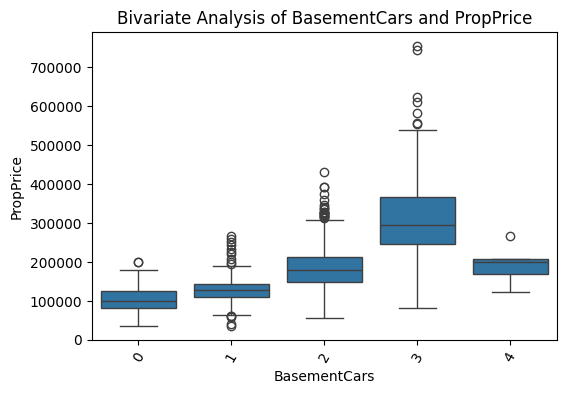

In [118]:
plt.figure(figsize=(6,4))
sns.boxplot(y='PropPrice', x='BasementCars', data=df)
plt.title(f"Bivariate Analysis of BasementCars and PropPrice")
plt.xticks(rotation=60)
plt.show()

 #### Insights for BasementCars vs PropPrice:
 ##### Here observed prices rise with garage capacity and diminishing returns after 2–3 cars which shows the availability of parking positively impacts property prices, though additional spaces beyond standard capacity offer diminishing marginal value.

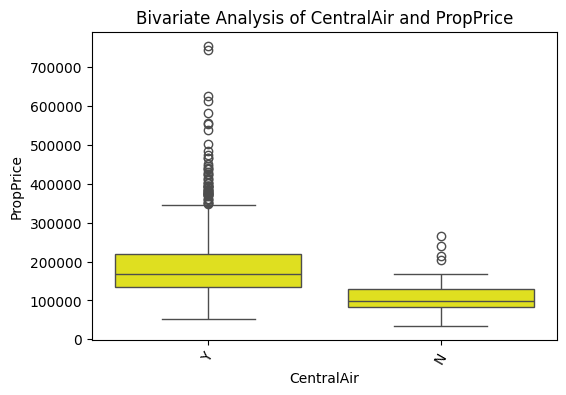

In [117]:
plt.figure(figsize=(6,4))
sns.boxplot(y='PropPrice', x='CentralAir', data=df, color='Yellow')
plt.title(f"Bivariate Analysis of CentralAir and PropPrice")
plt.xticks(rotation=60)
plt.show()

 #### Insights for CentralAir vs PropPrice:
 ##### Here observed Properties with central air have higher median prices which shows that the central air conditioning increases property desirability and is associated with higher sale prices.

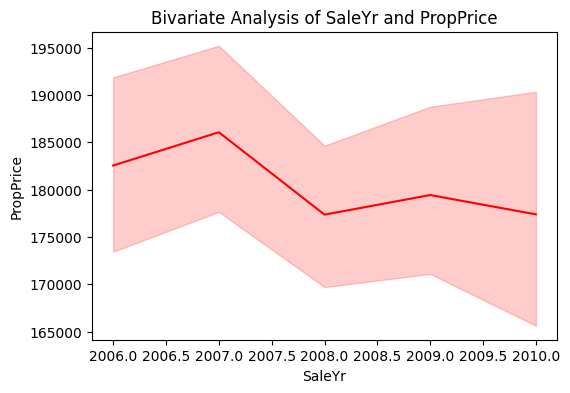

In [119]:
plt.figure(figsize=(6,4))
sns.lineplot(y='PropPrice', x='SaleYr', data=df, color='red')
plt.title(f"Bivariate Analysis of SaleYr and PropPrice")
plt.show()

 #### Insights for SaleYr vs PropPrice:
 ##### Here observed the Overall upward movement with slight dips which shows that Property prices show temporal variation, reflecting broader market trends and economic conditions.

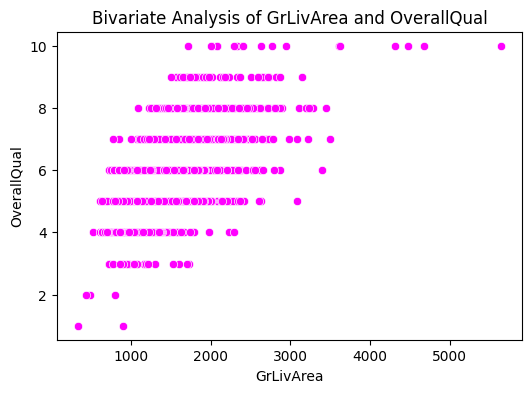

In [126]:
plt.figure(figsize=(6,4))
sns.scatterplot(y='OverallQual', x='GrLivArea', data=df, color='magenta')
plt.title(f"Bivariate Analysis of GrLivArea and OverallQual")
plt.show()

 #### Insights for GrLivArea vs OverallQual:
 ##### Here observed that the larger properties generally have higher quality ratings, though size and quality remain independent contributors to value.

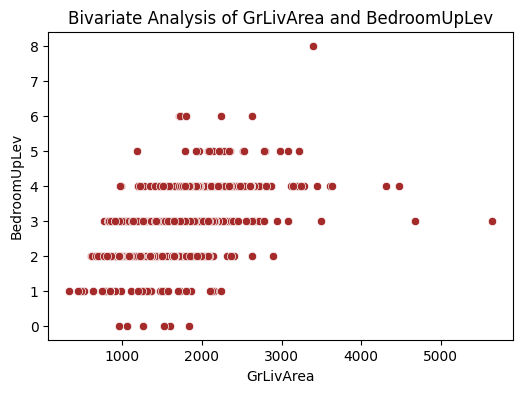

In [125]:
plt.figure(figsize=(6,4))
sns.scatterplot(y='BedroomUpLev', x='GrLivArea', data=df, color='Brown')
plt.title(f"Bivariate Analysis of GrLivArea and BedroomUpLev")
plt.show()

 #### Insights for BedroomUpLev vs GrLivArea:
 ##### Here observed that the houses with more bedrooms usually have larger living areas, but inefficient layouts exist where bedroom count does not scale proportionally with space.

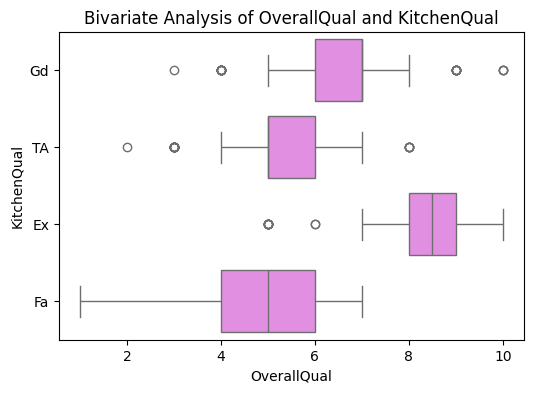

In [124]:
plt.figure(figsize=(6,4))
sns.boxplot(y='KitchenQual', x='OverallQual', data=df, color='Violet')
plt.title(f"Bivariate Analysis of OverallQual and KitchenQual")
plt.show()

 #### Insights for KitchenQual vs OverallQual:
 ##### Here observed that the higher kitchen quality strongly aligns with higher overall quality, reinforcing kitchen quality as a proxy for construction standards.

 ### c) Multivariate Analysis:

<Axes: >

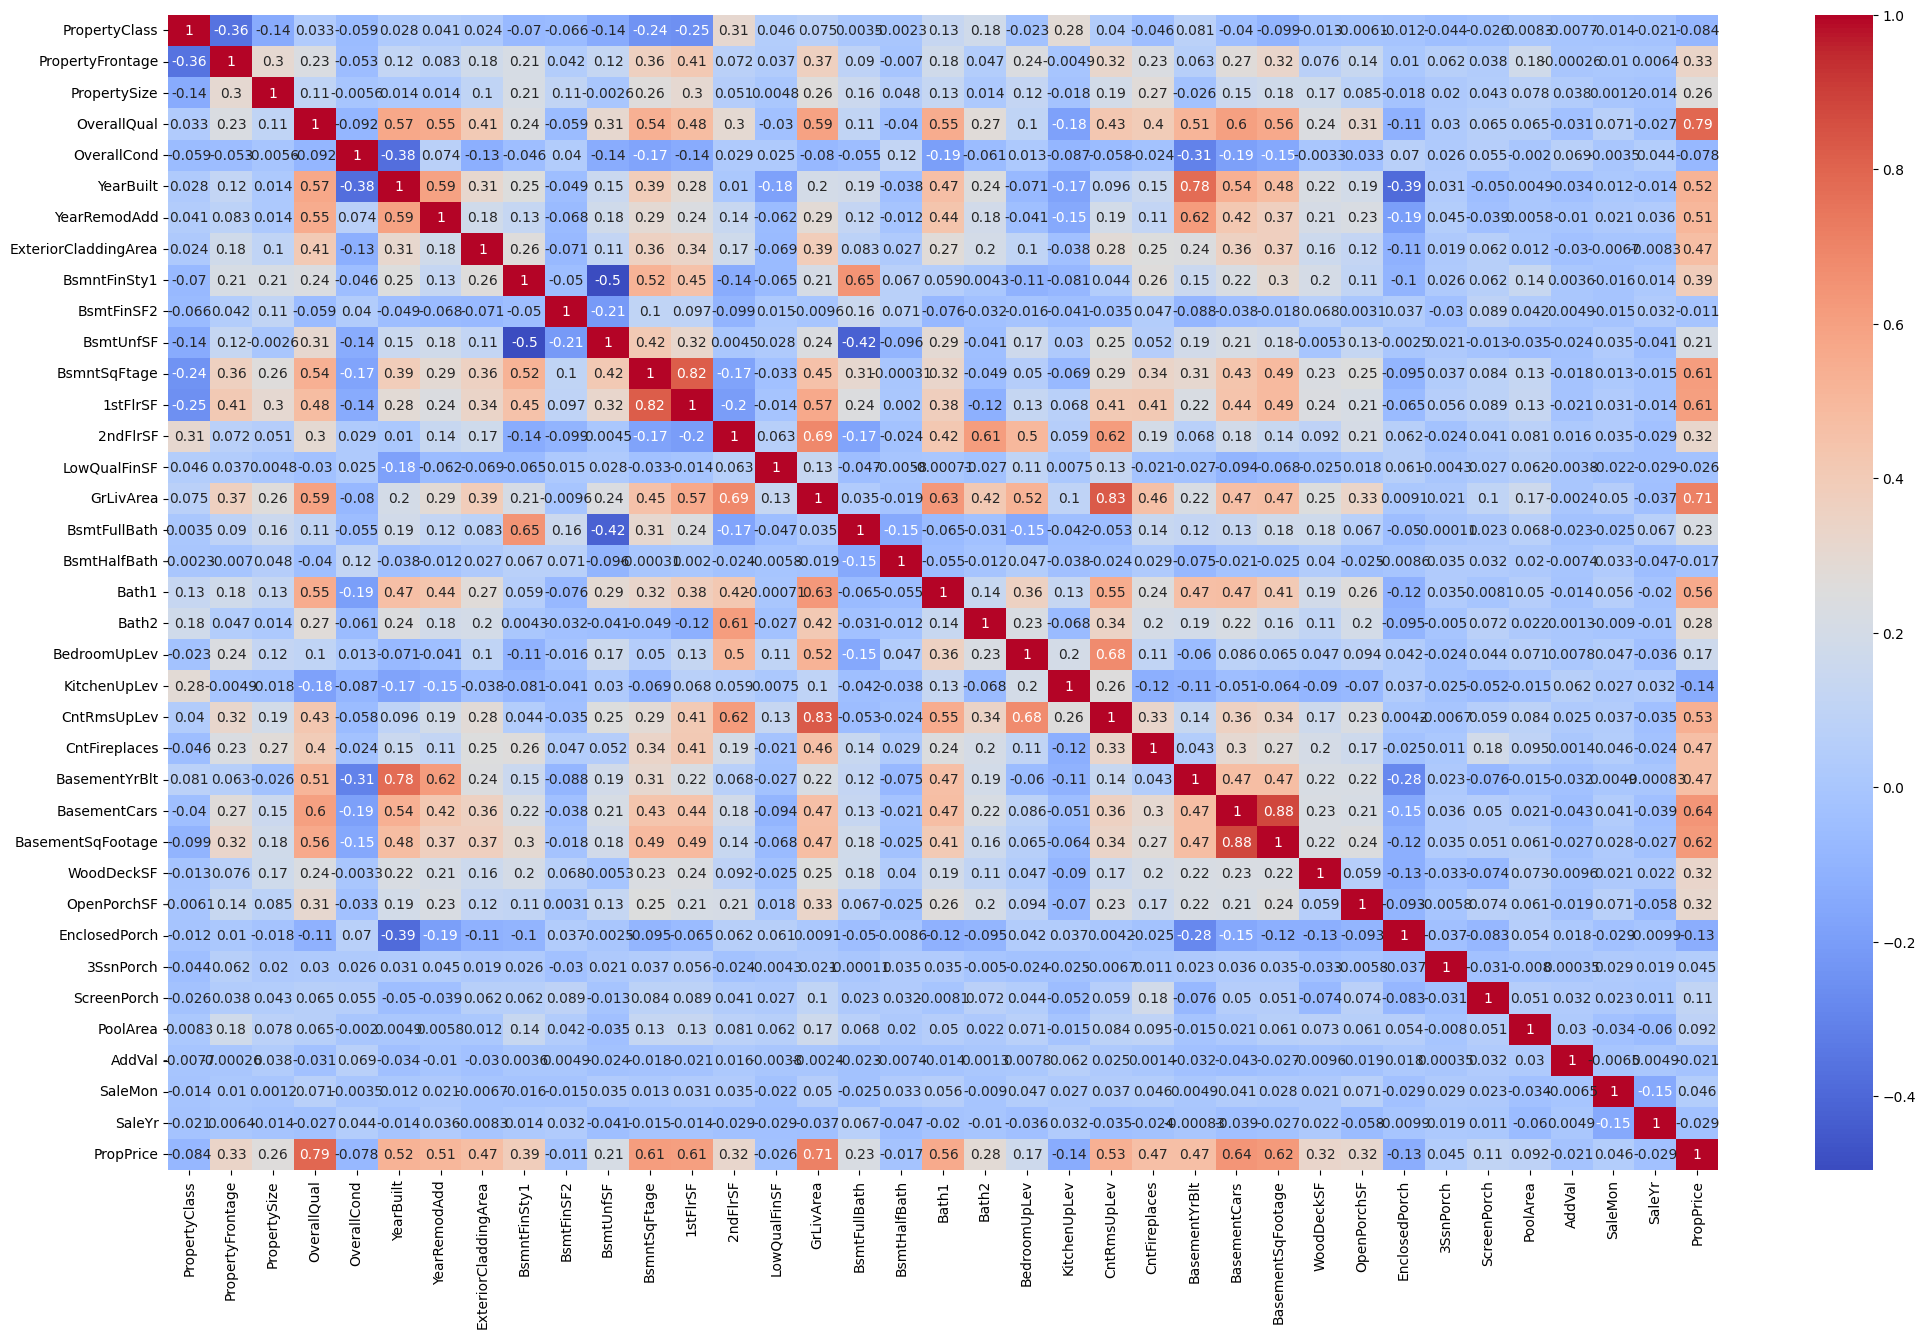

In [28]:
plt.figure(figsize=(25, 15))
sns.heatmap(co_re, annot=True, cmap='coolwarm')

 #### Insights for Multivariate Analysis:
 ##### Correlation Heatmap:
 ##### 1. Shows pairwise linear relationships
 ##### 2. Values range from –1 to +1
 ##### 3. Helps detect redundant variables

 ##### Observations:
 ##### 1. Strong Positive Correlations
 ##### 2. GrLivArea ↔ 1stFlrSF
 ##### 3. GrLivArea ↔ TotalArea
 ##### 4. BasementSqFootage ↔ BasementCars
 ##### 5. Bath1 ↔ CntRmsUpLev
 ##### Moderate Correlations
 ##### 1. YearBuilt ↔ OverallQual
 ##### 2. KitchenQual ↔ OverallQual
 ##### 3. BedroomUpLev ↔ CntRmsUpLev
 ##### Weak Correlations
 ##### 1. SaleMon with most features
 ##### 2. LowQualFinSF with price-related variables

 ##### Interpretation:
 ##### The correlation heatmap reveals strong multicollinearity among size-related variables such as living area, floor area, and total area. Quality-related variables also show moderate correlation, indicating overlapping information content.

 ## Feature Engineering:

In [29]:
df_fe = df.copy()

In [30]:
def col_or_zero(name):
    return df_fe[name] if name in df_fe.columns else 0

In [31]:
df_fe['TotalArea'] = col_or_zero('1stFlrSF') + col_or_zero('2ndFlrSF') + col_or_zero('BasementSqFootage')

In [32]:
df_fe['PropertyAge'] = col_or_zero('SaleYr') - col_or_zero('YearBuilt')

In [33]:
df_fe['RemodelAge'] = col_or_zero('SaleYr') - col_or_zero('YearRemodAdd')

In [34]:
df_fe['IsRemodeled'] = (col_or_zero('YearRemodAdd') > col_or_zero('YearBuilt')).astype(int)

In [35]:
df_fe['TotalBaths'] = (col_or_zero('Bath1') + 0.5*col_or_zero('Bath2') + col_or_zero('BsmtFullBath') + 0.5*col_or_zero('BsmtHalfBath'))

In [36]:
df_fe[['TotalArea','PropertyAge','RemodelAge','IsRemodeled','TotalBaths']].head()

,TotalArea,PropertyAge,RemodelAge,IsRemodeled,TotalBaths
0,2258,5,5,0,3.5
1,1722,31,31,0,2.5
2,2394,7,6,1,3.5
3,2359,91,36,1,2.0
4,3034,8,8,0,3.5


 ## Preprocessing: Numerical + Ordinal + Nominal:

In [37]:
TARGET = 'PropPrice'
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

In [38]:
# Ordinal columns
ordinal_cols = [c for c in [
    'ExterQual','ExterCond','KitchenQual','HeatingEfficiency',
    'BasementQual','BasementCond',
    'BsmntFinish','BsmntMaintenance','BsmntVisibility',
    'BsmntFinRat1','BsmntFinQual1','QualFireplace','Functional','Grade'
] if c in X.columns]

In [39]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

In [40]:
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

In [41]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

In [42]:
print('Ordinal:', ordinal_cols)
print('Nominal count:', len(nominal_cols))
print('Numeric count:', len(num_cols))

Ordinal: ['ExterQual', 'ExterCond', 'KitchenQual', 'HeatingEfficiency', 'BasementQual', 'BasementCond', 'BsmntFinish', 'BsmntMaintenance', 'BsmntVisibility', 'BsmntFinRat1', 'BsmntFinQual1', 'QualFireplace', 'Functional', 'Grade']
Nominal count: 29
Numeric count: 41


In [43]:
# Orders 
qual_order = ['Po','Fa','TA','Gd','Ex']
func_order = ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ']
bsmt_finish_order = ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ']
exposure_order = ['None','No','Mn','Av','Gd']

In [44]:
ordinal_categories = []
for col in ordinal_cols:
    if col in ['ExterQual','ExterCond','KitchenQual','HeatingEfficiency','BasementQual','BasementCond','QualFireplace','BsmntFinQual1','BsmntFinRat1','BsmntMaintenance']:
        ordinal_categories.append(qual_order)
    elif col == 'Functional':
        ordinal_categories.append(func_order)
    elif col == 'BsmntFinish':
        ordinal_categories.append(bsmt_finish_order)
    elif col == 'BsmntVisibility':
        ordinal_categories.append(exposure_order)
    else:
        ordinal_categories.append(qual_order)

In [45]:
numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

In [46]:
ordinal_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

In [47]:
nominal_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NotAvailable')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [48]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('ord', ordinal_pipe, ordinal_cols),
        ('nom', nominal_pipe, nominal_cols),
    ],
    remainder='drop'
)

 ## Model Training (Train/Test Split):

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
X_train.shape, X_test.shape

((1168, 84), (292, 84))

 ## Evaluation (MAE, RMSE):

In [62]:
def evaluate_model(name, reg):
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', reg)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'pipeline': pipe}

In [63]:
results = [
    evaluate_model('LinearRegression', LinearRegression()),
    evaluate_model('DecisionTree', DecisionTreeRegressor(random_state=42)),
    evaluate_model('RandomForest', RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
]

In [64]:
pd.DataFrame([{k:v for k,v in r.items() if k!='pipeline'} for r in results]).sort_values('MAE')

,model,MAE,RMSE
2,RandomForest,17962.123211,30159.537530
0,LinearRegression,19947.674398,30469.332300
1,DecisionTree,26734.815068,42210.097868


 ## Save Best Model Pipeline:

In [65]:
best = min(results, key=lambda r: r['MAE'])
MODEL_PATH = 'best_property_price_model.joblib'
joblib.dump(best['pipeline'], MODEL_PATH)
print('Best model:', best['model'])
print('Saved to:', MODEL_PATH)

Best model: RandomForest
Saved to: best_property_price_model.joblib


 ## Predict on New Record:

In [66]:
loaded = joblib.load(MODEL_PATH)
sample = X_test.iloc[[0]].copy()
pred = loaded.predict(sample)[0]
print('Predicted:', pred)
print('Actual   :', y_test.iloc[0])

Predicted: 139246.75
Actual   : 154500
